# Análisis Exploratorio de Datos (EDA) — Panel EMBI × JLoss × GaR
**Fragilidad bancaria, riesgo de cola del crecimiento y spread soberano en economías emergentes**

Panel: Brasil, Chile, Colombia, México, Perú · 2010Q1–2022Q2 · frecuencia trimestral.

Este notebook produce **toda la materia prima de la sección de estadística descriptiva**:
estructura del panel, cobertura, tablas de descriptivos (global y por país), distribuciones,
series de tiempo, matriz de correlaciones, descomposición de varianza *within/between*,
persistencia, episodios de crisis y detección de atípicos. Las tablas clave se exportan a
CSV y LaTeX listas para el paper.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 11

OUTDIR = Path('eda_output'); OUTDIR.mkdir(exist_ok=True)
FIGDIR = OUTDIR / 'figuras'; FIGDIR.mkdir(exist_ok=True)
def savefig(name): plt.savefig(FIGDIR / f'{name}.png', dpi=140, bbox_inches='tight')


In [2]:
# --- Carga y preparación ---
df = pd.read_csv('Panel_final.csv')
df['t'] = pd.PeriodIndex(df['quarter'], freq='Q')
df['date'] = df['t'].dt.to_timestamp()
df['year'] = df['t'].dt.year
df = df.sort_values(['country', 't']).reset_index(drop=True)

# etiquetas legibles y unidades
LABELS = {
 'EMBI_bps':'Spread EMBI (pb)', 'JLoss':'Fragilidad bancaria JLoss',
 'GaR':'Growth-at-Risk (q05)', 'GaR_st':'GaR skew-t', 'ES':'Expected Shortfall',
 'prob_neg':'Prob. crecim. negativo', 'skew':'Asimetría', 'std':'Desv. condicional',
 'VIX':'VIX (estandarizado)', 'g_GDP':'Crecimiento PIB (estand.)',
 'debt_gdp':'Deuda/PIB (%)', 'fisc_bal':'Balance fiscal/PIB (%)',
 'res_gdp':'Reservas/PIB (%)', 'ca_gdp':'Cuenta corriente/PIB (%)',
 'infl_yoy':'Inflación YoY (%)', 'reer':'REER (índice)', 'JLoss_x_GaR':'JLoss × GaR'}

CORE   = ['EMBI_bps','JLoss','GaR','ES','prob_neg']
CTRLS  = ['debt_gdp','fisc_bal','res_gdp','ca_gdp','infl_yoy','reer','VIX']
ALLV   = CORE + ['GaR_st','skew','std','g_GDP'] + CTRLS
_missing_allv = [c for c in ALLV if c not in df.columns]
if _missing_allv:
    print(f'Nota: {_missing_allv} no está en la versión reconstruida de Panel_final.csv '
          f'(GaR reentrenado sobre gar_panel_all15.csv no exporta el ajuste skew-t parametrico); '
          f'se excluye de ALLV. Ver Sección 13 para el skew-t, que usa gar_panel_latam.csv directamente.')
    ALLV = [c for c in ALLV if c in df.columns]
print('Dimensiones:', df.shape)
df.head()

Nota: ['GaR_st'] no está en la versión reconstruida de Panel_final.csv (GaR reentrenado sobre gar_panel_all15.csv no exporta el ajuste skew-t parametrico); se excluye de ALLV. Ver Sección 13 para el skew-t, que usa gar_panel_latam.csv directamente.
Dimensiones: (293, 36)


,country,quarter,EMBI_bps,embi_source,JLoss,GaR,prob_neg,ES,ER,mean,...,US_HY_spread_log,OnOffRun_spread_log,X_control_idx,X_control_idx_ncomp,debt_gdp_log,X_dom_idx,X_global_idx,t,date,year
0,brazil,2007Q4,209.6093,BCRP_real,4.8601,0.0488,0.0000,0.0411,0.0798,0.0627,...,NaN,-0.2062,-0.4807,3,NaN,-3.0959,0.8270,2007Q4,2007-10-01,2007
1,brazil,2008Q1,257.8479,BCRP_real,5.7249,0.0410,0.0000,0.0345,0.0749,0.0554,...,NaN,-0.3784,0.2324,3,NaN,0.3166,0.1903,2008Q1,2008-01-01,2008
2,brazil,2008Q2,214.3040,BCRP_real,4.4452,0.0437,0.0000,0.0389,0.0727,0.0574,...,NaN,-0.3640,0.3236,3,NaN,0.3439,0.3135,2008Q2,2008-04-01,2008
3,brazil,2008Q3,252.5307,BCRP_real,8.8366,0.0432,0.0000,0.0409,0.0794,0.0580,...,NaN,-0.3357,0.3479,3,NaN,0.3022,0.3707,2008Q3,2008-07-01,2008
4,brazil,2008Q4,481.5725,BCRP_real,23.6320,-0.0193,0.0879,-0.0262,0.0391,0.0163,...,NaN,-1.0727,-1.0166,3,NaN,0.1444,-1.5971,2008Q4,2008-10-01,2008


## 1. Estructura del panel y cobertura

In [3]:
n_country = df['country'].nunique()
n_periods = df['t'].nunique()
print(f'Países: {n_country} | Trimestres distintos: {n_periods} | Observaciones: {len(df)}')
print(f'Panel balanceado teórico: {n_country*n_periods} | balance real: {len(df)/(n_country*n_periods):.1%}')

cov = (df.groupby('country')
         .agg(N=('quarter','size'), inicio=('quarter','min'), fin=('quarter','max'))
         .reset_index())
cov

Países: 5 | Trimestres distintos: 59 | Observaciones: 293
Panel balanceado teórico: 295 | balance real: 99.3%


,country,N,inicio,fin
0,brazil,59,2007Q4,2022Q2
1,chile,57,2007Q4,2021Q4
2,colombia,59,2007Q4,2022Q2
3,mexico,59,2007Q4,2022Q2
4,peru,59,2007Q4,2022Q2


## 2. Datos faltantes

In [4]:
miss = (df[ALLV].isna().mean()*100).round(1).sort_values(ascending=False)
miss = miss[miss>0]
if len(miss):
    print('Columnas con faltantes (%):'); print(miss.to_string())
    print('\nDetalle por país de las columnas con huecos:')
    for col in miss.index:
        sub = df[df[col].isna()].groupby('country')['quarter'].agg(['size','min','max'])
        print(f'\n[{col}]'); print(sub.to_string())
else:
    print('Sin faltantes.')
# Nota: debt_gdp suele faltar para Chile (WDI GC.* sin cobertura) -> usar IMF WEO para versión final.

Columnas con faltantes (%):
infl_yoy   13.7000
fisc_bal   13.7000
reer       13.7000
ca_gdp     13.7000
res_gdp    13.7000
debt_gdp   12.6000
GaR         4.1000
ES          4.1000
prob_neg    4.1000
std         4.1000
skew        4.1000

Detalle por país de las columnas con huecos:

[infl_yoy]
          size     min     max
country                       
brazil       8  2007Q4  2009Q3
chile        8  2007Q4  2009Q3
colombia     8  2007Q4  2009Q3
mexico       8  2007Q4  2009Q3
peru         8  2007Q4  2009Q3

[fisc_bal]
          size     min     max
country                       
brazil       8  2007Q4  2009Q3
chile        8  2007Q4  2009Q3
colombia     8  2007Q4  2009Q3
mexico       8  2007Q4  2009Q3
peru         8  2007Q4  2009Q3

[reer]
          size     min     max
country                       
brazil       8  2007Q4  2009Q3
chile        8  2007Q4  2009Q3
colombia     8  2007Q4  2009Q3
mexico       8  2007Q4  2009Q3
peru         8  2007Q4  2009Q3

[ca_gdp]
          size     min  

## 3. Estadística descriptiva (tabla principal del paper)

Tabla global con media, desviación, mínimo, cuartiles, máximo y N. Se exporta a CSV y LaTeX.

In [5]:
def describe_block(d, cols):
    s = d[cols].describe(percentiles=[.25,.5,.75]).T
    s = s[['count','mean','std','min','25%','50%','75%','max']]
    s.columns = ['N','Media','Desv.','Mín','p25','Mediana','p75','Máx']
    s.index = [LABELS.get(c,c) for c in cols]
    return s.round(3)

desc = describe_block(df, CORE + ['skew','std','g_GDP'] + CTRLS)
desc.to_csv(OUTDIR/'tabla_descriptiva_global.csv')
# LaTeX (booktabs) listo para el paper
with open(OUTDIR/'tabla_descriptiva_global.tex','w') as f:
    f.write(desc.to_latex(escape=True, column_format='lrrrrrrrr',
            caption='Estadística descriptiva del panel (2010Q1–2022Q2).',
            label='tab:desc'))
desc

,N,Media,Desv.,Mín,p25,Mediana,p75,Máx
Spread EMBI (pb),293.0000,221.4890,86.1600,114.8830,161.2860,196.5990,256.1850,590.5710
Fragilidad bancaria JLoss,293.0000,5.8650,8.2600,1.5530,2.1930,2.4640,4.8540,46.8330
Growth-at-Risk (q05),281.0000,0.0030,0.0390,-0.1890,-0.0110,0.0070,0.0250,0.1040
Expected Shortfall,281.0000,-0.0030,0.0390,-0.1910,-0.0190,0.0020,0.0200,0.0760
Prob. crecim. negativo,281.0000,0.1430,0.2700,0.0000,0.0000,0.0000,0.1160,1.0000
Asimetría,281.0000,-0.0010,0.1590,-0.7020,-0.0740,0.0170,0.0750,0.4820
Desv. condicional,281.0000,0.0130,0.0040,0.0050,0.0110,0.0120,0.0140,0.0290
Crecimiento PIB (estand.),293.0000,-0.1330,1.1420,-5.3220,-0.5600,-0.0920,0.3360,5.1750
Deuda/PIB (%),256.0000,45.4190,24.0880,4.6390,24.1620,41.3270,65.2610,98.7100
Balance fiscal/PIB (%),253.0000,-3.2040,2.6490,-12.4360,-4.5010,-2.7170,-1.8630,2.7660


In [6]:
# Descriptivos por país (media y desviación) para variables centrales
by_country = (df.groupby('country')[CORE]
                .agg(['mean','std']).round(3))
by_country.columns = [f'{LABELS.get(v,v)} ({s})' for v,s in by_country.columns]
by_country.to_csv(OUTDIR/'tabla_descriptiva_por_pais.csv')
by_country.T

country,brazil,chile,colombia,mexico,peru
Spread EMBI (pb) (mean),268.0240,161.6610,224.3560,267.6830,183.6910
Spread EMBI (pb) (std),78.3640,47.9090,81.2180,94.3900,64.4840
Fragilidad bancaria JLoss (mean),16.0960,2.9020,4.5630,3.2080,2.4550
Fragilidad bancaria JLoss (std),13.6510,2.0860,3.4420,2.1840,0.7110
Growth-at-Risk (q05) (mean),-0.0040,0.0060,0.0060,-0.0140,0.0240
Growth-at-Risk (q05) (std),0.0360,0.0350,0.0410,0.0370,0.0370
Expected Shortfall (mean),-0.0100,0.0010,0.0000,-0.0210,0.0180
Expected Shortfall (std),0.0370,0.0350,0.0400,0.0360,0.0370
Prob. crecim. negativo (mean),0.2140,0.0980,0.1110,0.2250,0.0480
Prob. crecim. negativo (std),0.3090,0.2250,0.2640,0.3060,0.1710


## 4. Distribuciones univariadas

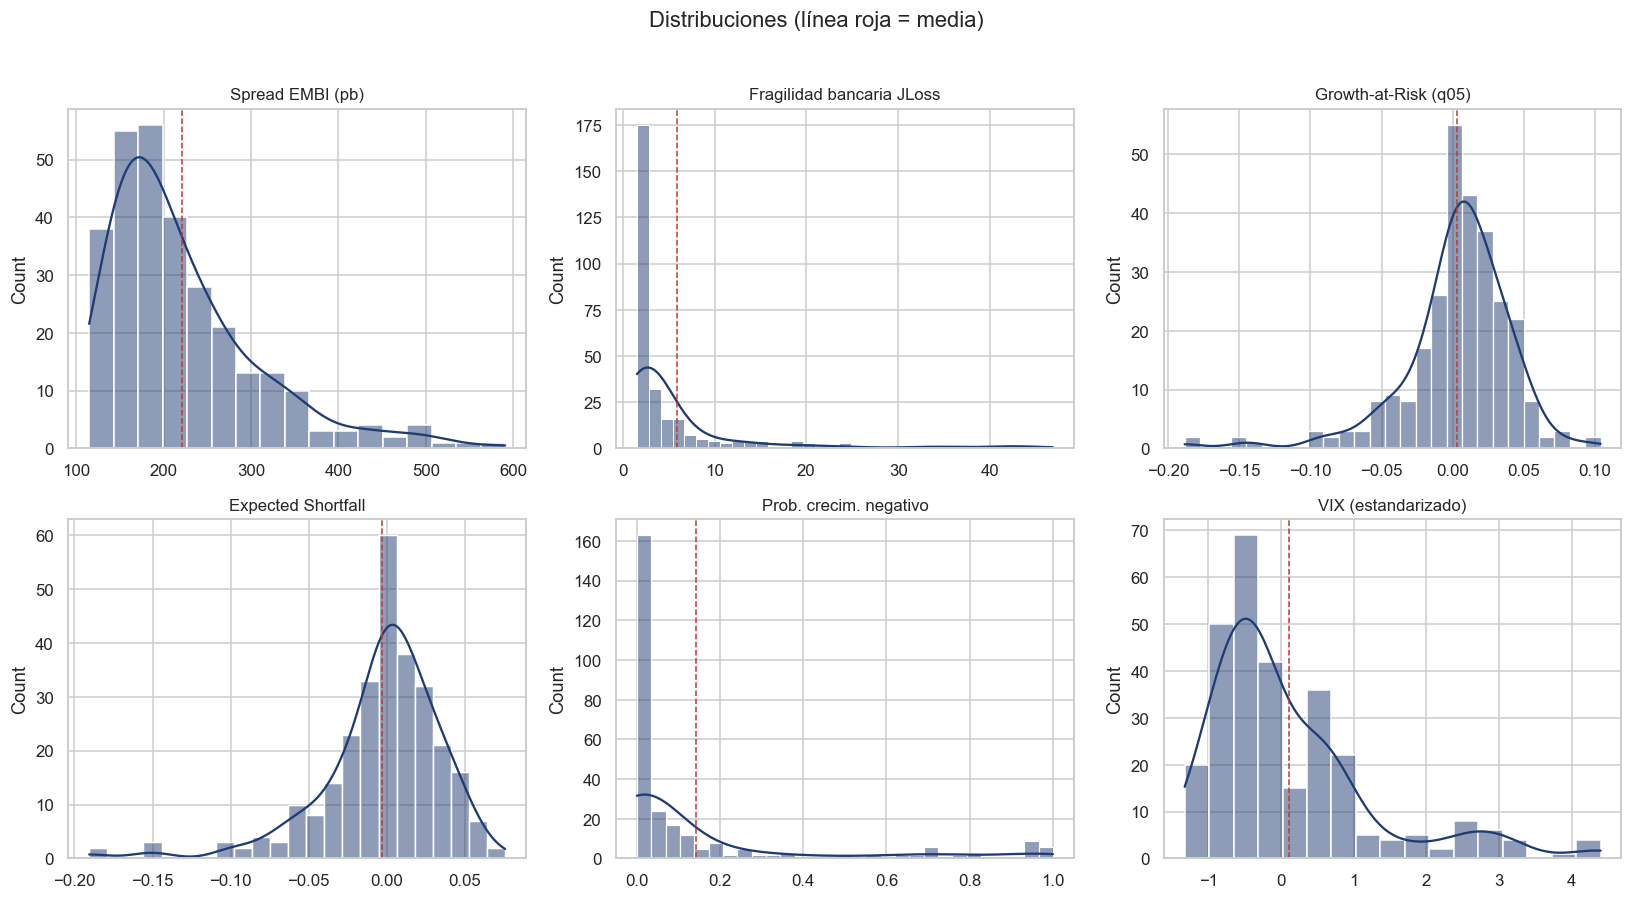

                           Asimetría  Curtosis
Spread EMBI (pb)              1.4800    2.3300
Fragilidad bancaria JLoss     3.1800   10.1700
Growth-at-Risk (q05)         -1.5700    5.3100
Expected Shortfall           -1.6100    4.6700
Prob. crecim. negativo        2.1100    3.2000
VIX (estandarizado)           1.6800    2.7800


In [7]:
vars_dist = ['EMBI_bps','JLoss','GaR','ES','prob_neg','VIX']
fig, axes = plt.subplots(2,3, figsize=(15,8)); axes=axes.ravel()
for i,v in enumerate(vars_dist):
    sns.histplot(df[v], kde=True, ax=axes[i], color='#1f3b73')
    axes[i].set_title(LABELS.get(v,v)); axes[i].set_xlabel('')
    axes[i].axvline(df[v].mean(), color='#c0392b', ls='--', lw=1)
fig.suptitle('Distribuciones (línea roja = media)', y=1.02)
plt.tight_layout(); savefig('04_distribuciones'); plt.show()

# Asimetría y curtosis (justifican transformaciones / colas pesadas)
from scipy.stats import skew, kurtosis
shape = pd.DataFrame({
    'Asimetría':[skew(df[v].dropna()) for v in vars_dist],
    'Curtosis' :[kurtosis(df[v].dropna()) for v in vars_dist]}, index=[LABELS[v] for v in vars_dist]).round(2)
print(shape.to_string())

C:\Users\HOME\AppData\Local\Temp\ipykernel_18220\30169988.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='country', y=v, ax=ax, palette='Blues')
C:\Users\HOME\AppData\Local\Temp\ipykernel_18220\30169988.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='country', y=v, ax=ax, palette='Blues')
C:\Users\HOME\AppData\Local\Temp\ipykernel_18220\30169988.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='country', y=v, ax=ax, palette='Blues')


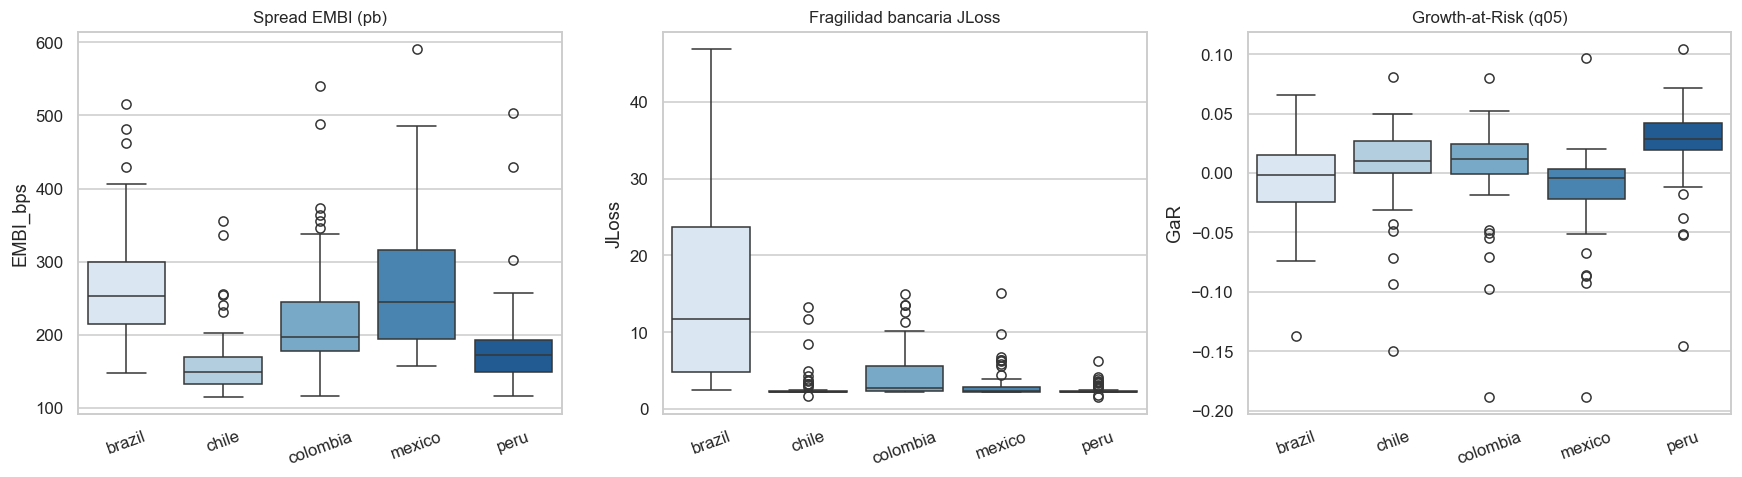

In [8]:
# Boxplots por país (heterogeneidad entre economías)
fig, axes = plt.subplots(1,3, figsize=(16,4.5))
for ax,v in zip(axes, ['EMBI_bps','JLoss','GaR']):
    sns.boxplot(data=df, x='country', y=v, ax=ax, palette='Blues')
    ax.set_title(LABELS[v]); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); savefig('04b_boxplots_pais'); plt.show()

## 5. Series de tiempo por país

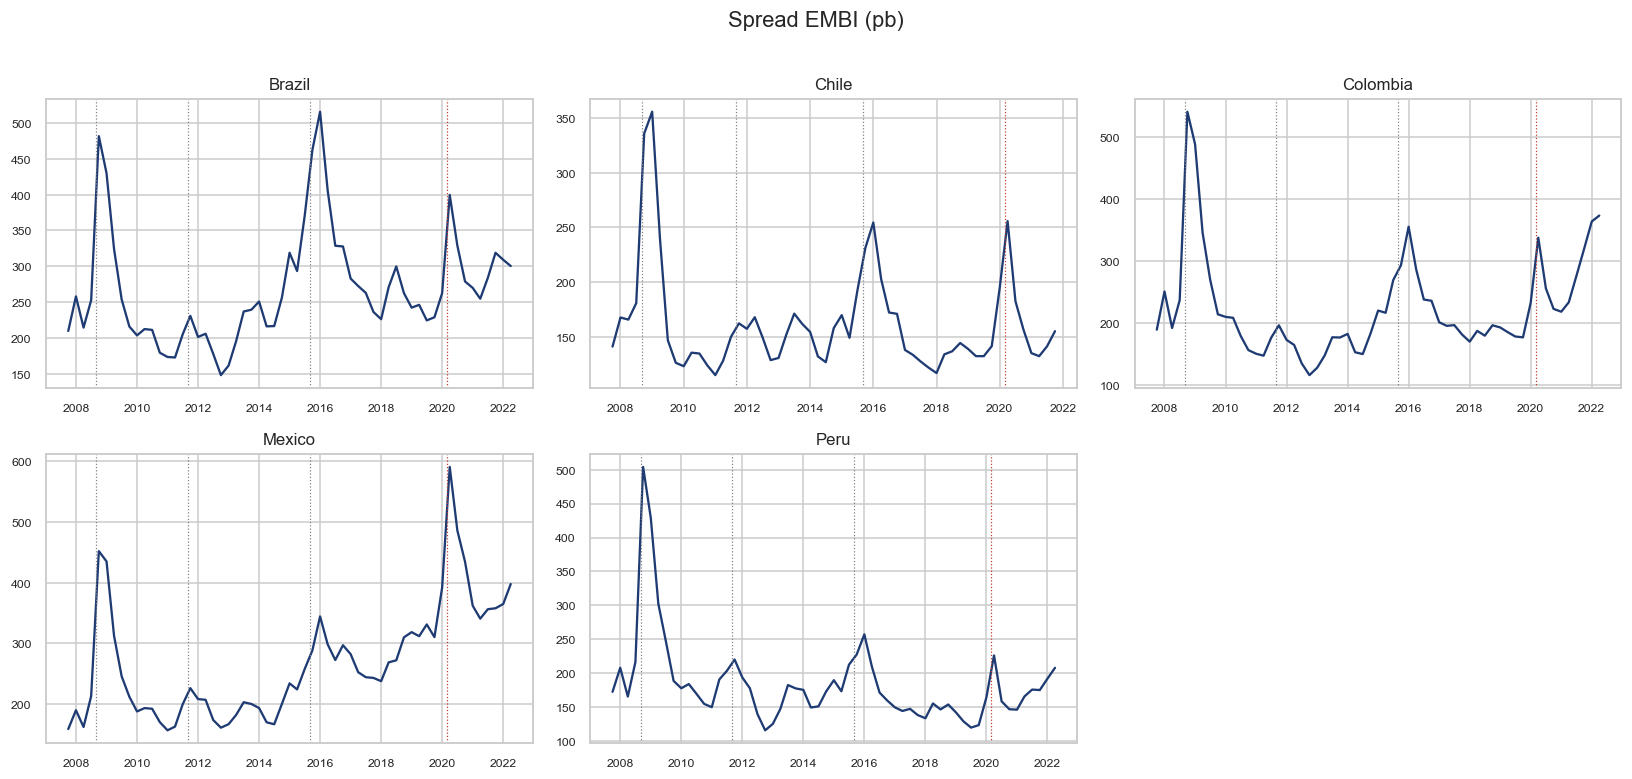

In [9]:
def panel_timeseries(var, color='#1f3b73', logy=False):
    fig, axes = plt.subplots(2,3, figsize=(15,7)); axes=axes.ravel()
    for i,(c,g) in enumerate(df.groupby('country')):
        g=g.sort_values('date')
        axes[i].plot(g['date'], g[var], color=color, lw=1.5)
        axes[i].set_title(c.capitalize()); axes[i].tick_params(labelsize=8)
        if logy: axes[i].set_yscale('log')
        for yr,lab,col in [('2011-09','UE','grey'),('2015-09','Commodity','grey'),('2020-03','COVID','#c0392b'),('2008-09','Subprime Crisis','grey')]:
            axes[i].axvline(pd.Timestamp(yr), color=col, ls=':', lw=.8)
    axes[-1].axis('off')
    fig.suptitle(LABELS.get(var,var), y=1.01); plt.tight_layout()
panel_timeseries('EMBI_bps'); savefig('05_ts_embi'); plt.show()

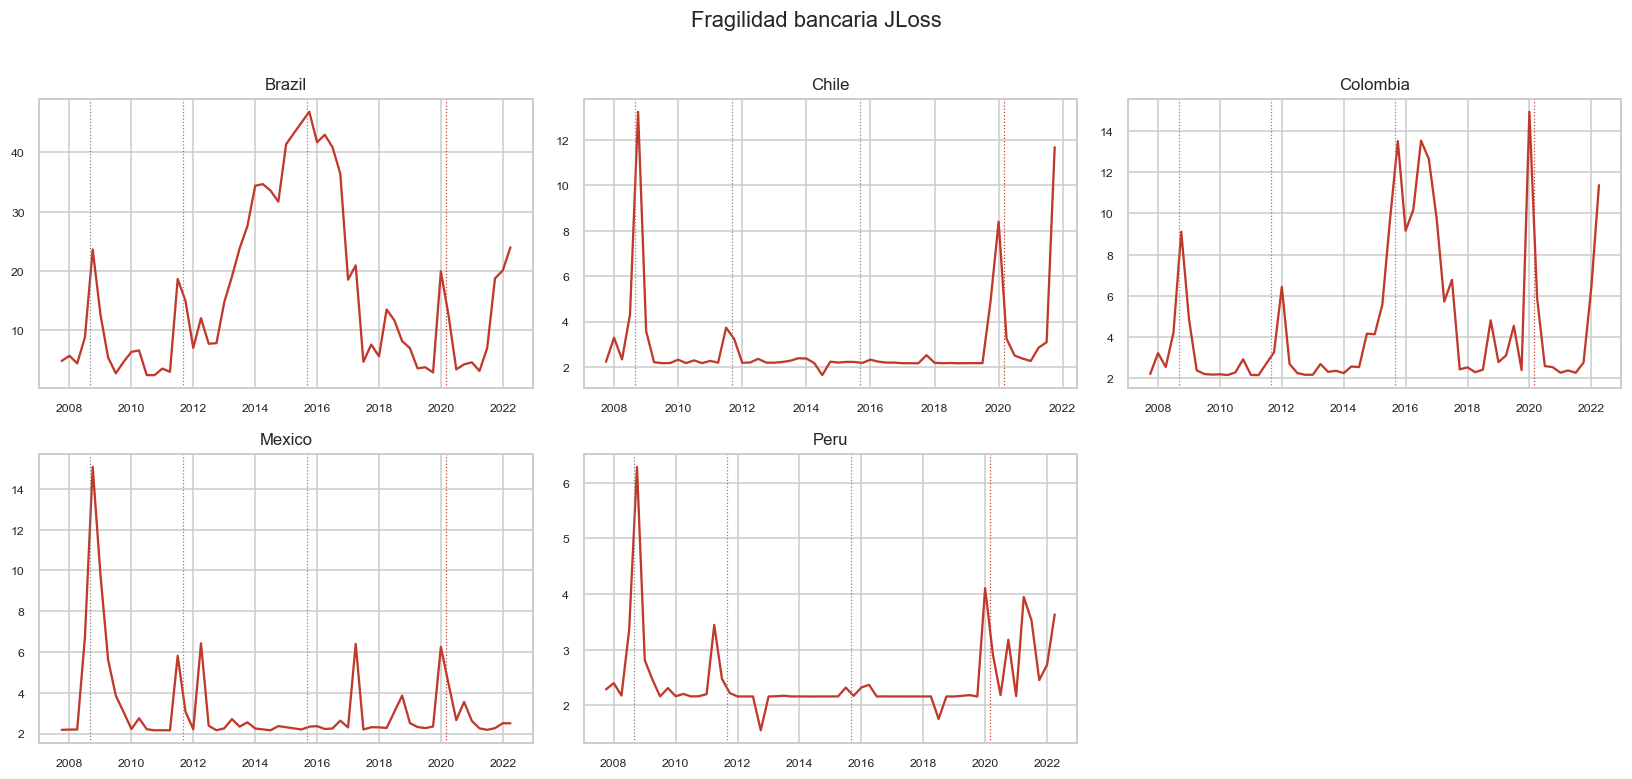

In [10]:
panel_timeseries('JLoss', color='#c0392b'); savefig('05_ts_jloss'); plt.show()

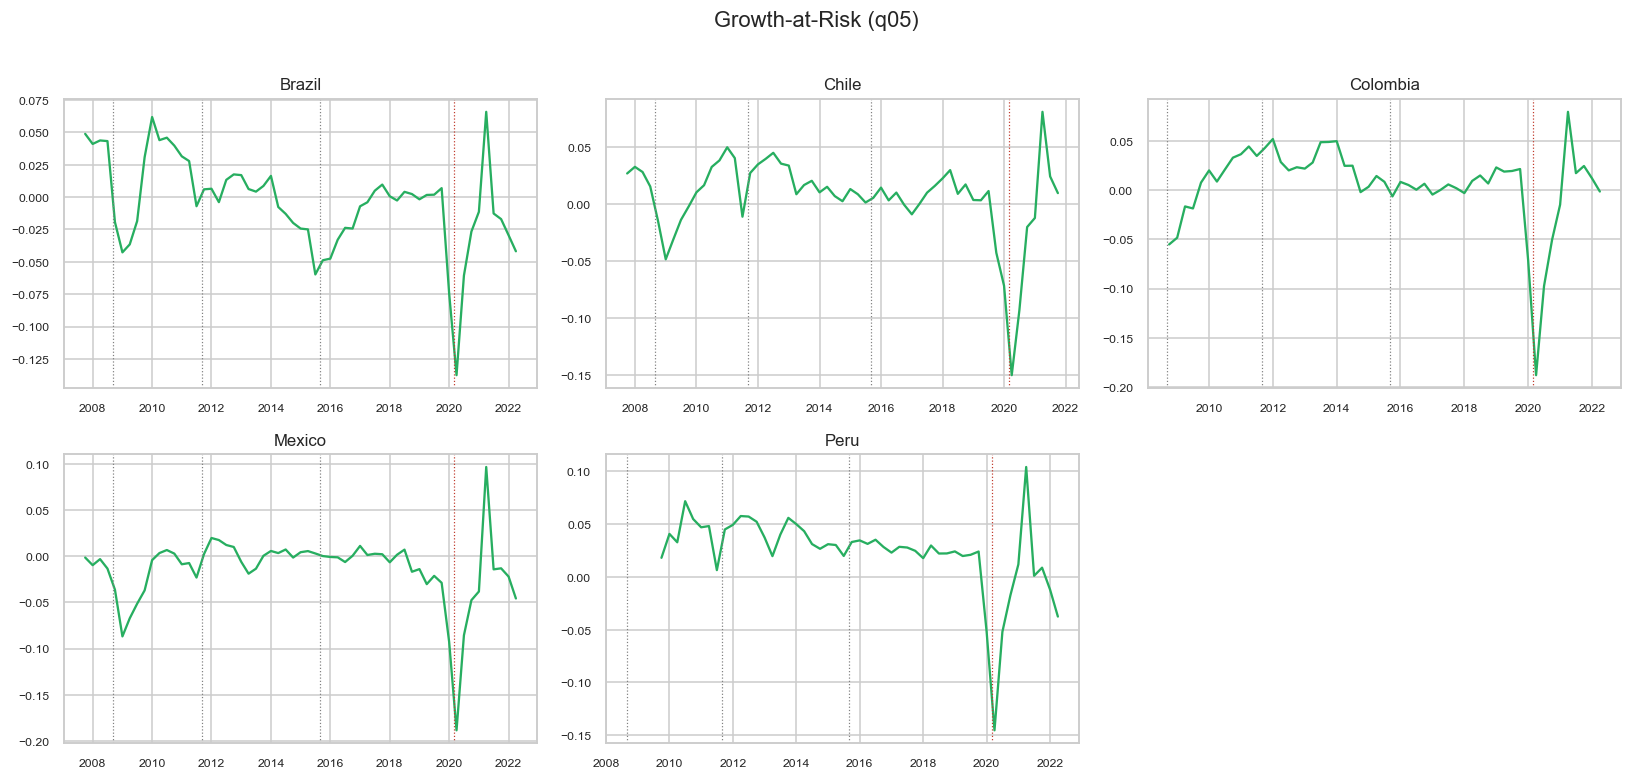

In [11]:
panel_timeseries('GaR', color='#27ae60'); savefig('05_ts_gar'); plt.show()

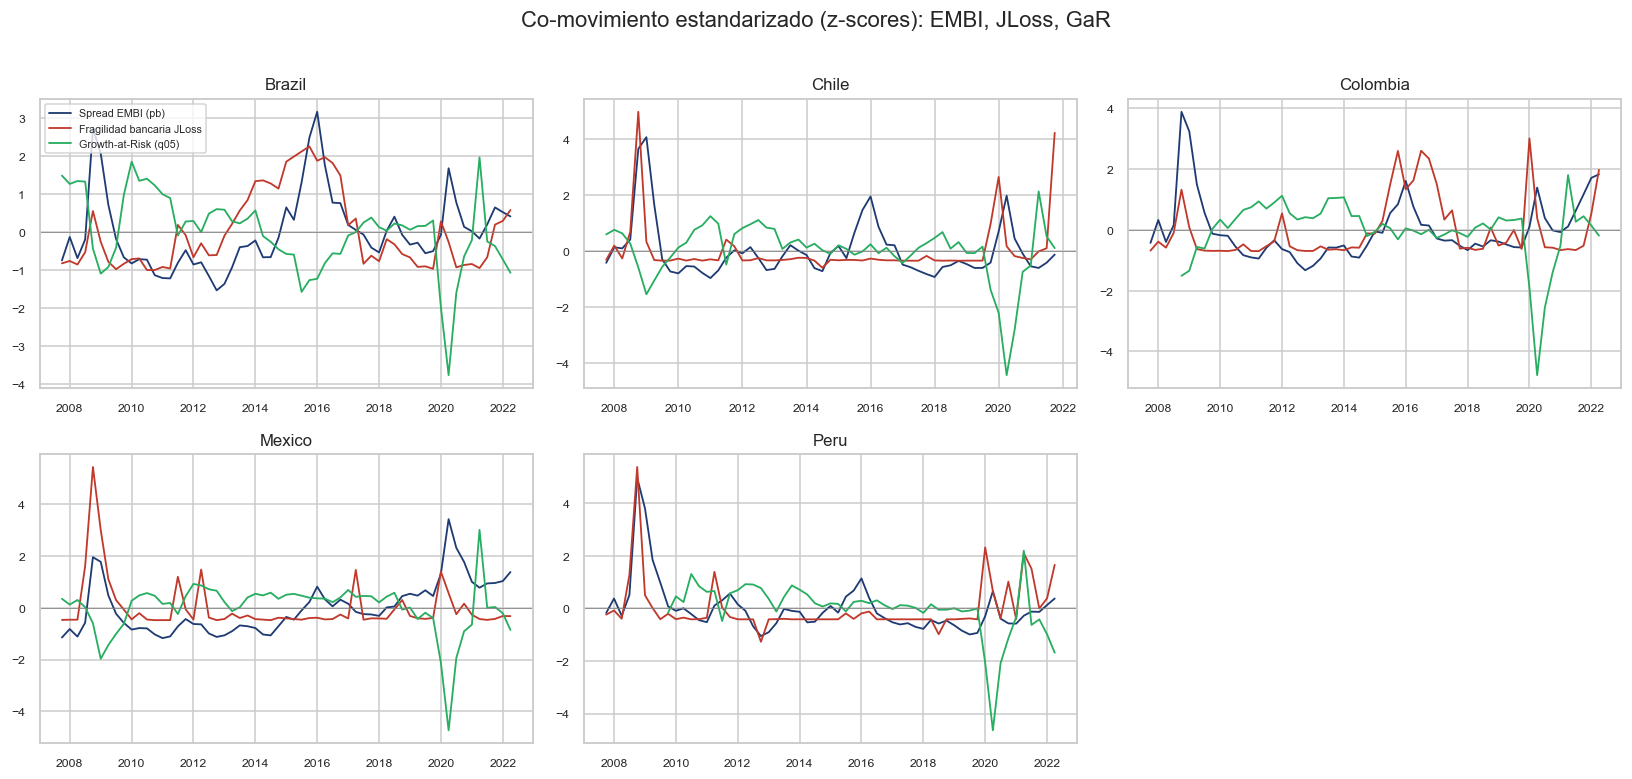

In [12]:
# EMBI, JLoss y GaR superpuestos por país (triple eje conceptual via estandarización)
fig, axes = plt.subplots(2,3, figsize=(15,7)); axes=axes.ravel()
for i,(c,g) in enumerate(df.groupby('country')):
    g=g.sort_values('date')
    for v,col in [('EMBI_bps','#1f3b73'),('JLoss','#c0392b'),('GaR','#27ae60')]:
        z=(g[v]-g[v].mean())/g[v].std()
        axes[i].plot(g['date'], z, color=col, lw=1.2, label=LABELS[v])
    axes[i].set_title(c.capitalize()); axes[i].tick_params(labelsize=8)
    axes[i].axhline(0, color='grey', lw=.5)
axes[-1].axis('off'); axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle('Co-movimiento estandarizado (z-scores): EMBI, JLoss, GaR', y=1.01)
plt.tight_layout(); savefig('05_comovimiento'); plt.show()

## 6. Relaciones bivariadas y la interacción central

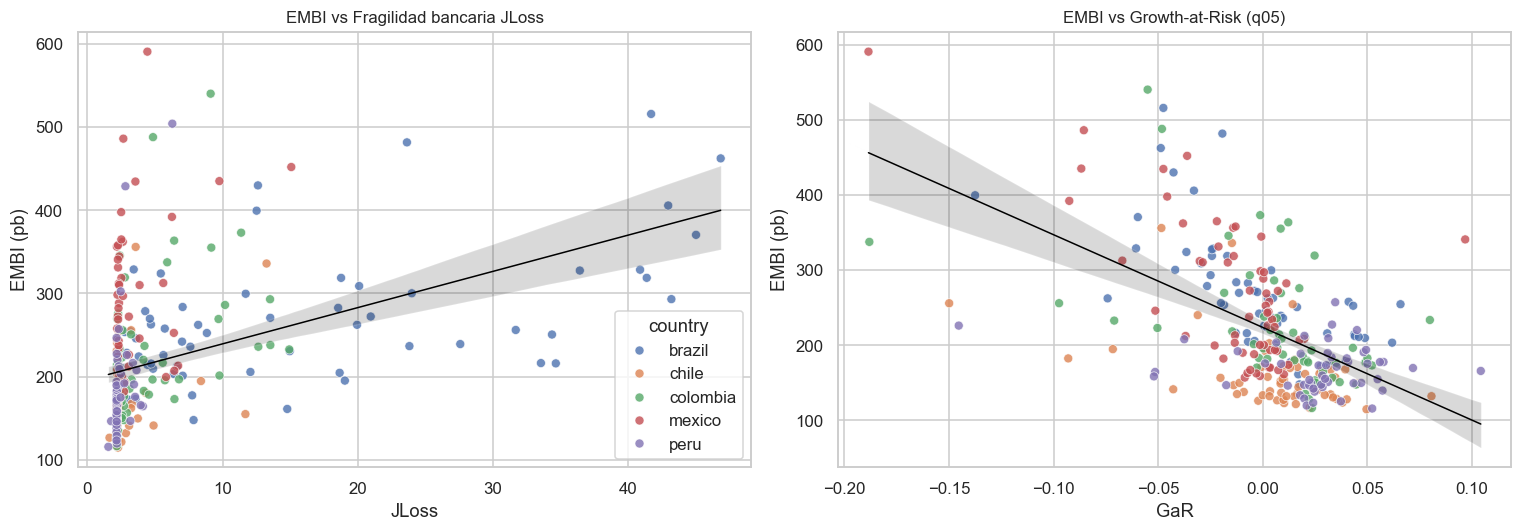

In [13]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
for ax,v in zip(axes, ['JLoss','GaR']):
    sns.scatterplot(data=df, x=v, y='EMBI_bps', hue='country', ax=ax, s=35, alpha=.8)
    sns.regplot(data=df, x=v, y='EMBI_bps', scatter=False, ax=ax, color='black', line_kws={'lw':1})
    ax.set_title(f'EMBI vs {LABELS[v]}'); ax.set_ylabel('EMBI (pb)')
    if v!='JLoss': ax.legend_.remove()
plt.tight_layout(); savefig('06_scatter_embi'); plt.show()

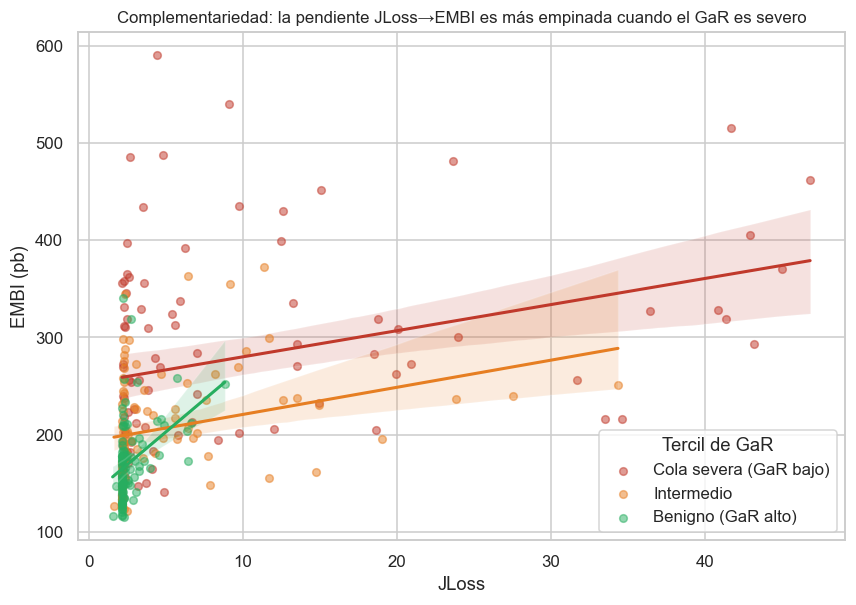

In [14]:
# Visualización de la COMPLEMENTARIEDAD: relación JLoss–EMBI según severidad de la cola (terciles de GaR)
df['GaR_tercil'] = pd.qcut(df['GaR'], 3, labels=['Cola severa (GaR bajo)','Intermedio','Benigno (GaR alto)'])
fig, ax = plt.subplots(figsize=(9,6))
palette = {'Cola severa (GaR bajo)':'#c0392b','Intermedio':'#e67e22','Benigno (GaR alto)':'#27ae60'}
for terc,g in df.groupby('GaR_tercil', observed=True):
    sns.regplot(data=g, x='JLoss', y='EMBI_bps', scatter_kws={'s':25,'alpha':.5},
                line_kws={'lw':2}, color=palette[terc], label=str(terc), ax=ax)
ax.set_title('Complementariedad: la pendiente JLoss→EMBI es más empinada cuando el GaR es severo')
ax.set_xlabel('JLoss'); ax.set_ylabel('EMBI (pb)'); ax.legend(title='Tercil de GaR')
savefig('06_complementariedad'); plt.show()

## 7. Matriz de correlaciones

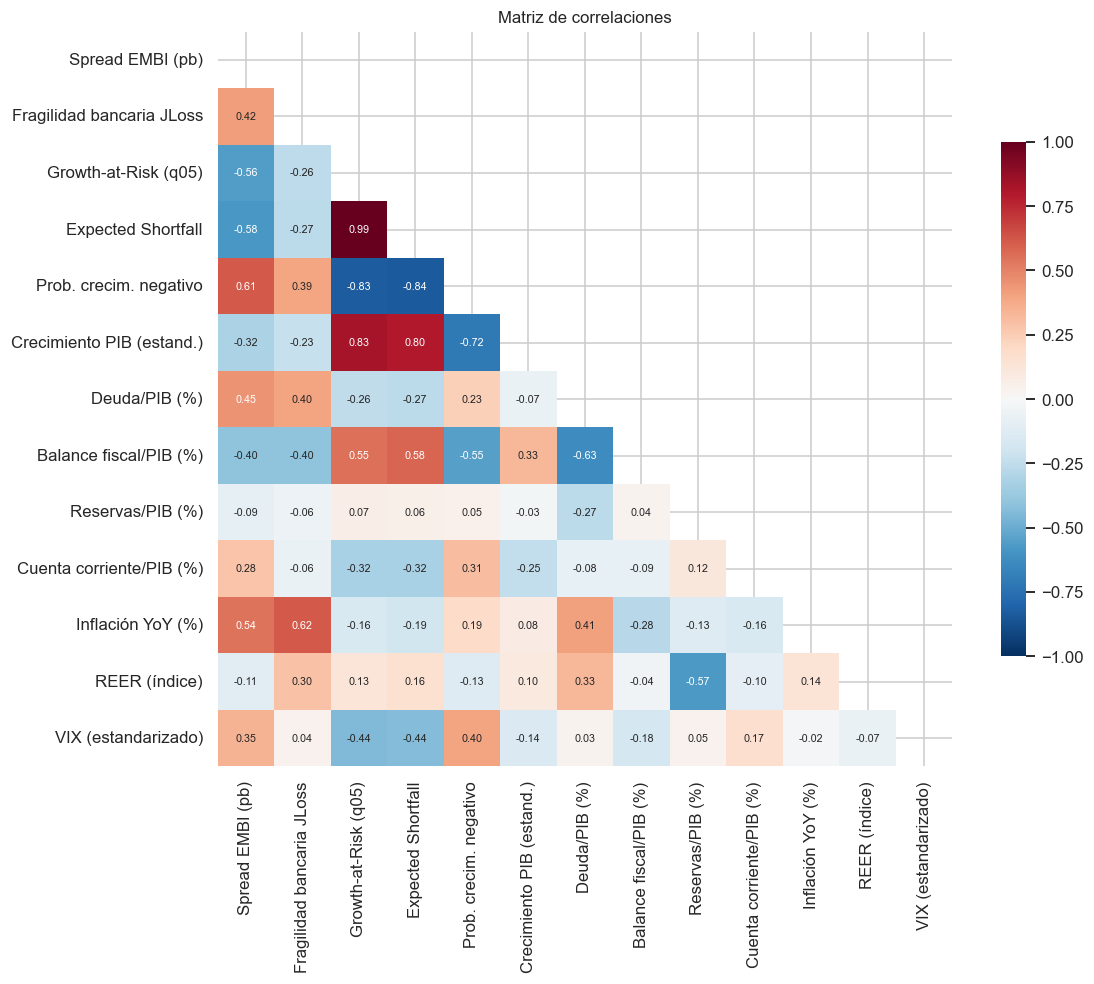


Pares con |corr|>0.6 (vigilar en regresión):
  Spread EMBI (pb) ~ Prob. crecim. negativo: +0.614
  Fragilidad bancaria JLoss ~ Inflación YoY (%): +0.617
  Growth-at-Risk (q05) ~ Expected Shortfall: +0.993
  Growth-at-Risk (q05) ~ Prob. crecim. negativo: -0.828
  Growth-at-Risk (q05) ~ Crecimiento PIB (estand.): +0.832
  Expected Shortfall ~ Prob. crecim. negativo: -0.838
  Expected Shortfall ~ Crecimiento PIB (estand.): +0.800
  Prob. crecim. negativo ~ Crecimiento PIB (estand.): -0.716
  Deuda/PIB (%) ~ Balance fiscal/PIB (%): -0.626

Nota: GaR–crecimiento alta por construcción (GaR es un cuantil del crecimiento) -> NO incluir g_GDP junto a GaR.


In [15]:
corr_vars = CORE + ['g_GDP'] + CTRLS
cm = df[corr_vars].corr()
cm.index=[LABELS.get(c,c) for c in corr_vars]; cm.columns=[LABELS.get(c,c) for c in corr_vars]
fig, ax = plt.subplots(figsize=(11,9))
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink':.7}, annot_kws={'size':7}, ax=ax)
ax.set_title('Matriz de correlaciones'); plt.tight_layout(); savefig('07_correlaciones'); plt.show()
cm.round(3).to_csv(OUTDIR/'matriz_correlaciones.csv')

# Alertas de multicolinealidad
print('\nPares con |corr|>0.6 (vigilar en regresión):')
cc = df[corr_vars].corr().abs()
for i in range(len(corr_vars)):
    for j in range(i+1,len(corr_vars)):
        if cc.iloc[i,j]>0.6:
            print(f'  {LABELS.get(corr_vars[i])} ~ {LABELS.get(corr_vars[j])}: {df[corr_vars].corr().iloc[i,j]:+.3f}')
print('\nNota: GaR–crecimiento alta por construcción (GaR es un cuantil del crecimiento) -> NO incluir g_GDP junto a GaR.')

In [16]:
# VIF (factor de inflación de varianza) para el bloque de regresores
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
vif_vars = ['JLoss','GaR','fisc_bal','res_gdp','ca_gdp','infl_yoy','reer','VIX']
X = add_constant(df[vif_vars].dropna())
vif = pd.DataFrame({'variable':[LABELS.get(v,v) for v in vif_vars],
    'VIF':[variance_inflation_factor(X.values, i+1) for i in range(len(vif_vars))]}).round(2)
print(vif.to_string(index=False))
print('\nRegla práctica: VIF>10 indica multicolinealidad problemática.')

                 variable    VIF
Fragilidad bancaria JLoss 2.1600
     Growth-at-Risk (q05) 2.1900
   Balance fiscal/PIB (%) 1.6300
         Reservas/PIB (%) 1.7500
 Cuenta corriente/PIB (%) 1.2100
        Inflación YoY (%) 1.7300
            REER (índice) 1.9500
      VIX (estandarizado) 1.2500

Regla práctica: VIF>10 indica multicolinealidad problemática.


## 8. Descomposición de varianza *within / between*

Para un panel con efectos fijos, lo que identifica los coeficientes es la variación **within**
(dentro de cada país en el tiempo). Aquí se reporta, estilo `xtsum` de Stata, cuánta variación
es total, entre países (*between*) y dentro de país (*within*).

In [17]:
def xtsum(d, var, group='country'):
    overall = d[var].std()
    between = d.groupby(group)[var].mean().std()
    gmean = d.groupby(group)[var].transform('mean')
    within = (d[var]-gmean + d[var].mean()).std()
    return overall, between, within

rows=[]
for v in CORE+['g_GDP','debt_gdp','fisc_bal','res_gdp','ca_gdp','infl_yoy','reer']:
    o,b,w = xtsum(df, v)
    rows.append({'variable':LABELS.get(v,v),'sd_total':o,'sd_between':b,'sd_within':w,
                 'within/total':w/o if o else np.nan})
vardec = pd.DataFrame(rows).round(3)
vardec.to_csv(OUTDIR/'descomposicion_within_between.csv', index=False)
print(vardec.to_string(index=False))
print('\nLectura: variables con within/total alto aportan más a la identificación con efectos fijos.')

                 variable  sd_total  sd_between  sd_within  within/total
         Spread EMBI (pb)   86.1600     48.2570    74.6040        0.8660
Fragilidad bancaria JLoss    8.2600      5.7840     6.4230        0.7780
     Growth-at-Risk (q05)    0.0390      0.0140     0.0370        0.9470
       Expected Shortfall    0.0390      0.0140     0.0370        0.9450
   Prob. crecim. negativo    0.2700      0.0770     0.2610        0.9670
Crecimiento PIB (estand.)    1.1420      0.2000     1.1280        0.9880
            Deuda/PIB (%)   24.0880     24.9280     8.9560        0.3720
   Balance fiscal/PIB (%)    2.6490      1.4520     2.3060        0.8710
         Reservas/PIB (%)    7.0510      7.3570     2.4480        0.3470
 Cuenta corriente/PIB (%)    1.7220      1.1860     1.3530        0.7860
        Inflación YoY (%)    1.8090      1.1470     1.4880        0.8220
            REER (índice)   19.6210     14.2930    14.8240        0.7560

Lectura: variables con within/total alto aportan m

## 9. Persistencia (autocorrelación) del spread y de JLoss

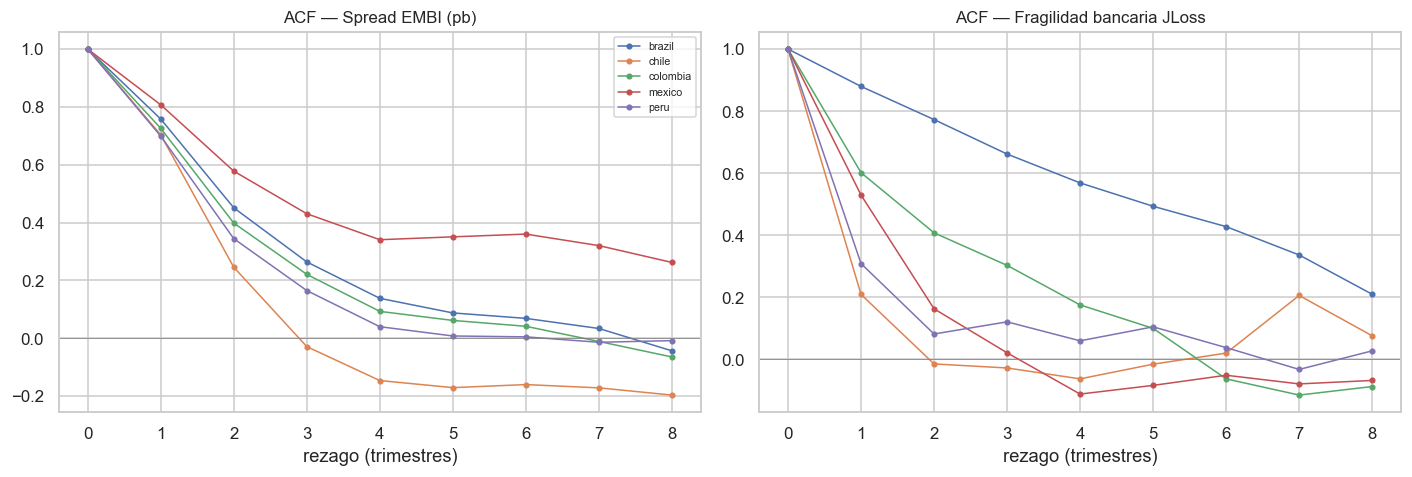

Spreads y JLoss muy persistentes -> motiva SE robustos a autocorrelación (Driscoll-Kraay) y/o specs dinámicas como robustez.


In [18]:
from statsmodels.tsa.stattools import acf
fig, axes = plt.subplots(1,2, figsize=(13,4.5))
for ax,v in zip(axes, ['EMBI_bps','JLoss']):
    for c,g in df.groupby('country'):
        a = acf(g.sort_values('t')[v].values, nlags=8, fft=False)
        ax.plot(range(len(a)), a, marker='o', ms=3, label=c, lw=1)
    ax.axhline(0, color='grey', lw=.5); ax.set_title(f'ACF — {LABELS[v]}')
    ax.set_xlabel('rezago (trimestres)')
axes[0].legend(fontsize=7)
plt.tight_layout(); savefig('09_persistencia'); plt.show()
print('Spreads y JLoss muy persistentes -> motiva SE robustos a autocorrelación (Driscoll-Kraay) y/o specs dinámicas como robustez.')

## 10. Episodios de estrés: medias por régimen de mercado global

In [19]:
# clasificar trimestres por nivel global de VIX (terciles) y comparar medias
df['regimen_VIX'] = pd.qcut(df['VIX'], 3, labels=['VIX bajo','VIX medio','VIX alto'])
tab = df.groupby('regimen_VIX', observed=True)[['EMBI_bps','JLoss','GaR','prob_neg']].mean().round(3)
print(tab.to_string())
tab.to_csv(OUTDIR/'medias_por_regimen_VIX.csv')

             EMBI_bps  JLoss     GaR  prob_neg
regimen_VIX                                   
VIX bajo     208.5830 6.6740  0.0140    0.0770
VIX medio    197.7010 5.3700  0.0140    0.0710
VIX alto     257.9390 5.5460 -0.0200    0.2950


## 11. Detección de atípicos

In [20]:
z = (df[CORE] - df[CORE].mean())/df[CORE].std()
out = df.loc[(z.abs()>3).any(axis=1), ['country','quarter']+CORE]
print(f'Observaciones con |z|>3 en alguna variable central: {len(out)}')
out.round(3)

Observaciones con |z|>3 en alguna variable central: 25


,country,quarter,EMBI_bps,JLoss,GaR,ES,prob_neg
4,brazil,2008Q4,481.5720,23.6320,-0.0190,-0.0260,0.0880
25,brazil,2014Q1,250.7140,34.3580,0.0160,0.0130,0.0000
26,brazil,2014Q2,216.0460,34.6410,-0.0080,-0.0190,0.2120
27,brazil,2014Q3,216.4050,33.5410,-0.0130,-0.0220,0.2950
28,brazil,2014Q4,256.1850,31.6780,-0.0200,-0.0340,0.3390
29,brazil,2015Q1,318.8170,41.3640,-0.0240,-0.0380,0.5870
30,brazil,2015Q2,293.2420,43.1870,-0.0250,-0.0300,0.7060
31,brazil,2015Q3,370.4680,45.0100,-0.0600,-0.0700,0.9340
32,brazil,2015Q4,462.3320,46.8330,-0.0490,-0.0610,0.9440
33,brazil,2016Q1,515.7100,41.6890,-0.0480,-0.0550,0.9550


## 12. Resumen de archivos exportados
Todo en la carpeta `eda_output/` (tablas) y `eda_output/figuras/` (PNG).

In [21]:
import os
print('Tablas:'); [print('  ', f) for f in sorted(os.listdir(OUTDIR)) if f.endswith(('.csv','.tex'))]
print('Figuras:'); [print('  ', f) for f in sorted(os.listdir(FIGDIR))]

Tablas:
   descomposicion_within_between.csv
   matriz_correlaciones.csv
   medias_por_regimen_VIX.csv
   tabla_descriptiva_global.csv
   tabla_descriptiva_global.tex
   tabla_descriptiva_por_pais.csv
Figuras:
   01_balance_panel.png
   04_distribuciones.png
   04b_boxplots_pais.png
   05_comovimiento.png
   05_ts_embi.png
   05_ts_gar.png
   05_ts_jloss.png
   06_complementariedad.png
   06_scatter_embi.png
   07_correlaciones.png
   09_persistencia.png
   13_anchura_colas.png
   13_cola_izquierda.png
   13_curva_gar_chile.png
   13_volatilidad_gar.png
   14_1_cobertura_tres_bases.png
   14_binscatter_regimen.png
   14_contabilidad_episodio.png
   14_contrafactual.png
   14_efecto_marginal.png
   14_forest_theta.png
   14_leave_one_out.png
   14_series_pais.png
   14_superficie_complementariedad.png
   14_umbral_hansen.png


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

---
# 13. Análisis del GaR: volatilidad, anchura de colas y forma de la distribución

Esta sección usa `gar_panel_latam.csv`, que conserva los momentos completos de la
distribución condicional del crecimiento (media, dispersión, anchura intercuantil 5–95,
*Expected Shortfall* y los parámetros del ajuste skew-t) necesarios para estudiar la
**forma** de la cola y su evolución temporal.

In [22]:
# Carga del panel GaR con momentos completos
gar = pd.read_csv('gar_panel_latam.csv')
gar['country'] = gar['country'].str.lower()
gar['t'] = pd.PeriodIndex(gar['quarter'], freq='Q')
gar['date'] = gar['t'].dt.to_timestamp()
gar = gar.sort_values(['country','t']).reset_index(drop=True)
gar[['country','quarter','GaR','GaR_st','ES','mean','std','iqr_05_95',
     'scale_st','skew_st','nu_st']].head()

,country,quarter,GaR,GaR_st,ES,mean,std,iqr_05_95,scale_st,skew_st,nu_st
0,brazil,2010Q1,0.0676,0.0676,0.0586,0.0915,0.0126,0.0567,0.0119,0.6302,2.1000
1,brazil,2010Q2,0.0138,0.0133,0.0134,0.0546,0.0169,0.0622,0.0156,-0.9006,2.1000
2,brazil,2010Q3,0.0500,0.0502,0.0265,0.0716,0.0106,0.0538,0.0112,0.6307,2.1000
3,brazil,2010Q4,0.0444,0.0446,0.0325,0.0660,0.0119,0.0571,0.0126,0.7461,2.1000
4,brazil,2011Q1,0.0310,0.0313,0.0259,0.0561,0.0124,0.0638,0.0143,0.7832,2.1000


## 13.1 Volatilidad del GaR

Dos lecturas complementarias de la volatilidad: (i) la **dispersión condicional** `std`
estimada en cada corte —cuánta incertidumbre rodea al pronóstico de crecimiento— y
(ii) la **volatilidad realizada** del propio GaR (desviación estándar móvil de 4
trimestres), que mide cuán inestable es la estimación del riesgo de cola en el tiempo.

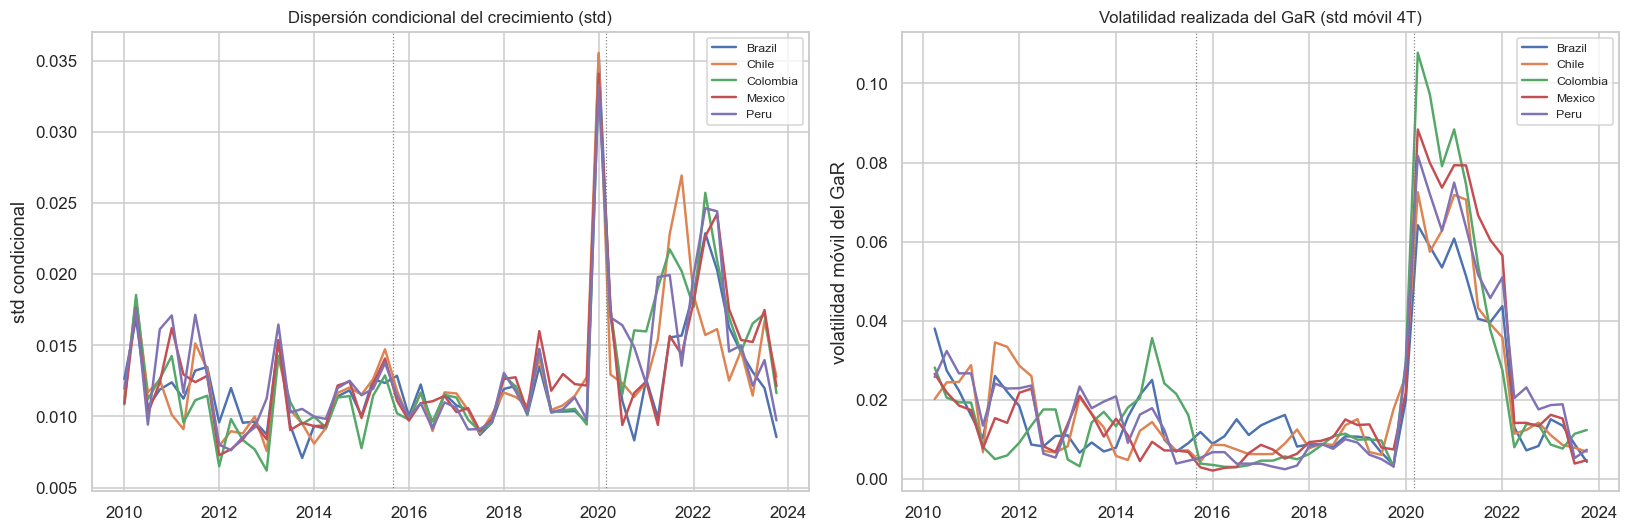

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (i) dispersión condicional por país
for c, g in gar.groupby('country'):
    axes[0].plot(g['date'], g['std'], lw=1.6, label=c.capitalize())
axes[0].set_title('Dispersión condicional del crecimiento (std)')
axes[0].set_ylabel('std condicional'); axes[0].legend(fontsize=8)
for yr in ['2015-09','2020-03']:
    axes[0].axvline(pd.Timestamp(yr), color='grey', ls=':', lw=.8)

# (ii) volatilidad realizada (móvil) del GaR
gar['GaR_vol4'] = gar.groupby('country')['GaR'].transform(
    lambda s: s.rolling(4, min_periods=2).std())
for c, g in gar.groupby('country'):
    axes[1].plot(g['date'], g['GaR_vol4'], lw=1.6, label=c.capitalize())
axes[1].set_title('Volatilidad realizada del GaR (std móvil 4T)')
axes[1].set_ylabel('volatilidad móvil del GaR'); axes[1].legend(fontsize=8)
for yr in ['2015-09','2020-03']:
    axes[1].axvline(pd.Timestamp(yr), color='grey', ls=':', lw=.8)
plt.tight_layout(); savefig('13_volatilidad_gar'); plt.show()

## 13.2 Anchura de las colas y su evolución temporal

Para cada país se reconstruye el **intervalo condicional 5–95%** del crecimiento usando
el cuantil inferior (`GaR` = percentil 5) y la anchura intercuantil (`iqr_05_95`), de
modo que el percentil 95 = `GaR + iqr_05_95`. La banda sombreada representa el rango
central de la distribución; su ensanchamiento señala mayor incertidumbre. La línea de
*Expected Shortfall* (`ES`, media de la cola izquierda) marca la profundidad de la cola
adversa. Las colas se ensanchan visiblemente en los episodios de estrés.

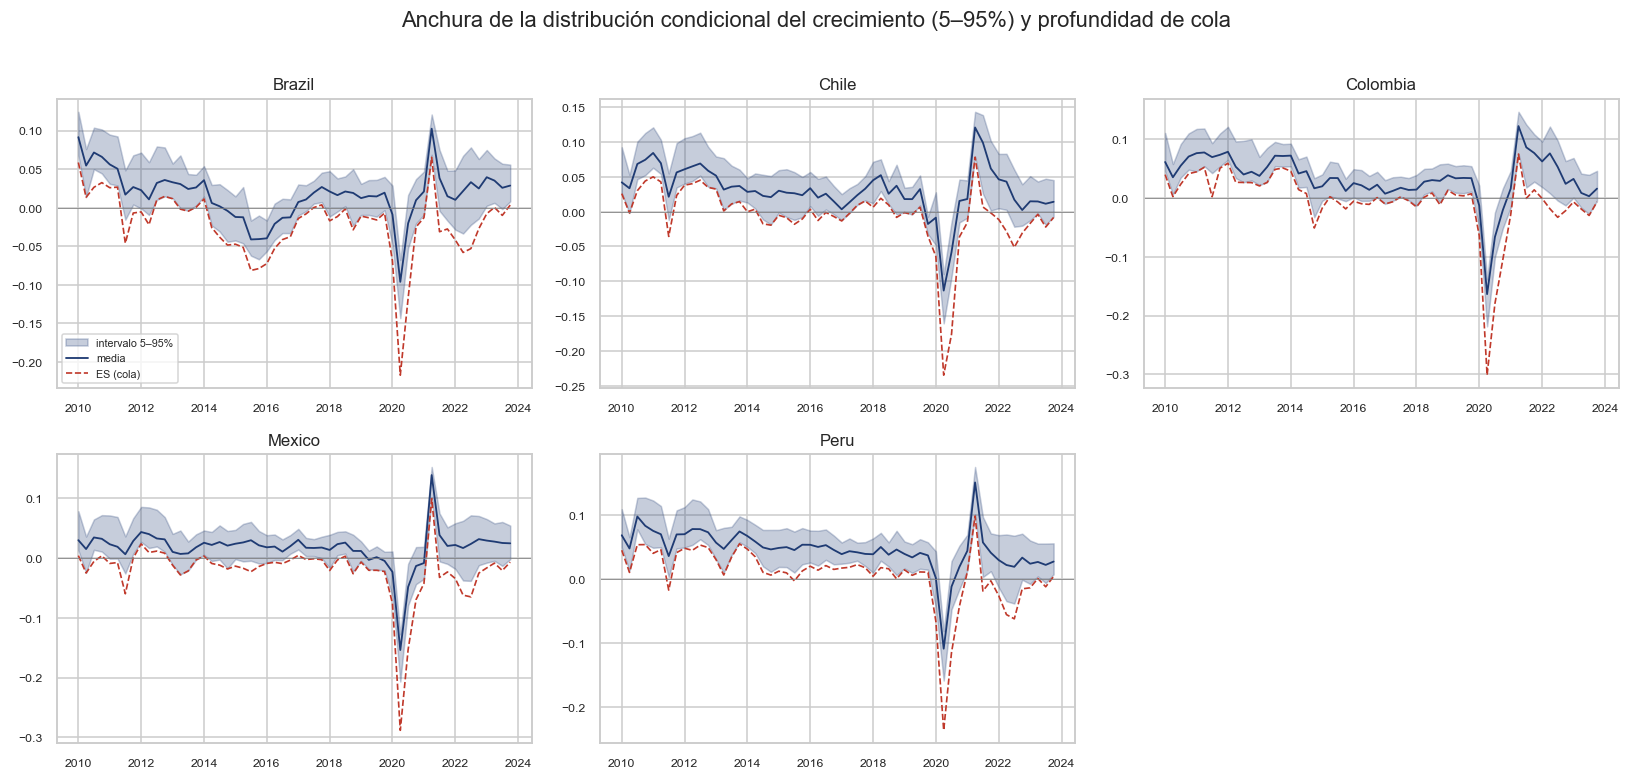

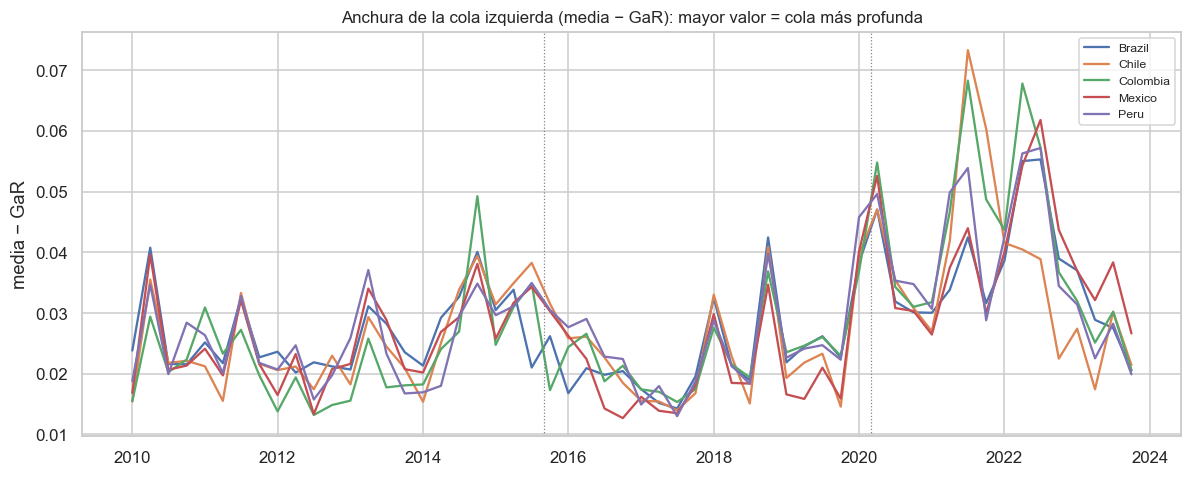

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7)); axes = axes.ravel()
for i, (c, g) in enumerate(gar.groupby('country')):
    g = g.sort_values('date')
    q05 = g['GaR']; q95 = g['GaR'] + g['iqr_05_95']
    axes[i].fill_between(g['date'], q05, q95, alpha=.25, color='#1f3b73',
                         label='intervalo 5–95%')
    axes[i].plot(g['date'], g['mean'], color='#1f3b73', lw=1.2, label='media')
    axes[i].plot(g['date'], g['ES'], color='#c0392b', lw=1.1, ls='--', label='ES (cola)')
    axes[i].axhline(0, color='grey', lw=.5)
    axes[i].set_title(c.capitalize()); axes[i].tick_params(labelsize=8)
axes[-1].axis('off'); axes[0].legend(fontsize=7, loc='lower left')
fig.suptitle('Anchura de la distribución condicional del crecimiento (5–95%) y profundidad de cola', y=1.01)
plt.tight_layout(); savefig('13_anchura_colas'); plt.show()

# Anchura de cola IZQUIERDA (media - GaR) por país en el tiempo
fig, ax = plt.subplots(figsize=(11,4.5))
for c, g in gar.groupby('country'):
    ax.plot(g['date'], g['mean'] - g['GaR'], lw=1.5, label=c.capitalize())
ax.set_title('Anchura de la cola izquierda (media − GaR): mayor valor = cola más profunda')
ax.set_ylabel('media − GaR'); ax.legend(fontsize=8)
for yr in ['2015-09','2020-03']: ax.axvline(pd.Timestamp(yr), color='grey', ls=':', lw=.8)
plt.tight_layout(); savefig('13_cola_izquierda'); plt.show()

## 13.3 Forma de la distribución del GaR para Chile en momentos específicos

Se reconstruye la **densidad condicional skew-t** (Azzalini; especificación de Adrian,
Boyarchenko y Giannone, 2019) a partir de los parámetros estimados —escala $\omega$
(`scale_st`), asimetría $\alpha$ (`skew_st`) y grados de libertad $\nu$ (`nu_st`)—,
recuperando la localización $\xi$ a partir de la media condicional. Se contrastan un
trimestre de **estrés** (GaR más negativo) y uno **benigno** para Chile, marcando el
cuantil 5% (GaR) y el *Expected Shortfall*. El desplazamiento a la izquierda y el
engrosamiento de la cola en el trimestre de estrés son la representación gráfica directa
del *growth-at-risk*.

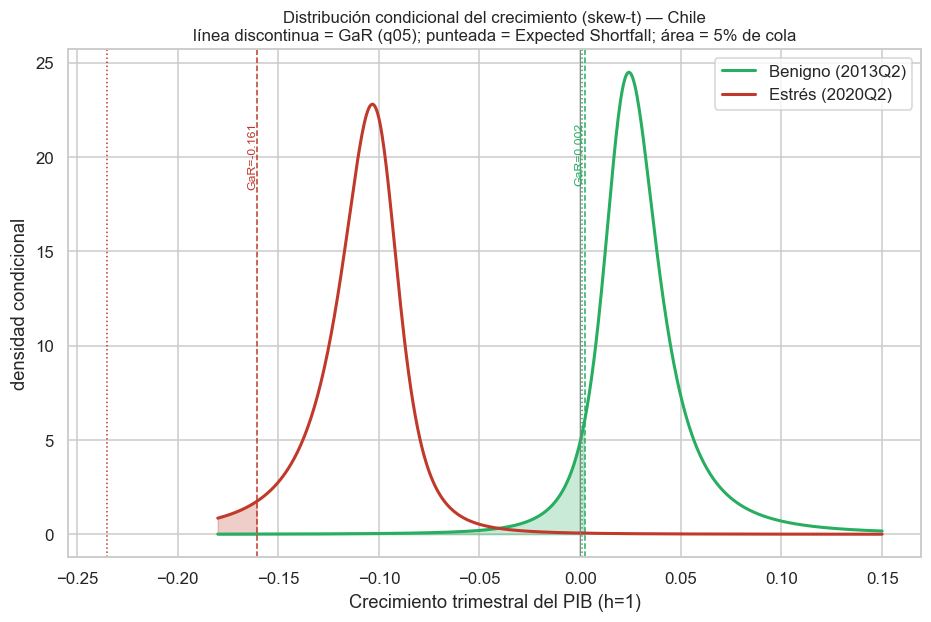

2013Q2: q05 skew-t reconstruido=-0.0043 | GaR_st reportado=0.0028 | GaR (directo)=0.0023
2020Q2: q05 skew-t reconstruido=-0.1491 | GaR_st reportado=-0.1597 | GaR (directo)=-0.1605


In [25]:
from scipy.stats import t as student_t
from scipy.special import gammaln

def skewt_pdf(y, xi, omega, alpha, nu):
    z = (y - xi) / omega
    arg = alpha * z * np.sqrt((nu + 1) / (z**2 + nu))
    return (2/omega) * student_t.pdf(z, nu) * student_t.cdf(arg, nu + 1)

def xi_from_mean(mean, omega, alpha, nu):
    # E[Y] = xi + omega*delta*sqrt(nu/pi)*Gamma((nu-1)/2)/Gamma(nu/2),  nu>1
    delta = alpha / np.sqrt(1 + alpha**2)
    b = np.sqrt(nu/np.pi) * np.exp(gammaln((nu-1)/2) - gammaln(nu/2))
    return mean - omega * delta * b

ch = gar[gar.country == 'chile'].copy()
q_stress = ch.loc[ch['GaR'].idxmin(), 'quarter']                 # cola más severa
q_calm   = ch.loc[(ch['GaR'] - ch['GaR'].median()).abs().idxmin(), 'quarter']  # típico

fig, ax = plt.subplots(figsize=(10, 6))
ygrid = np.linspace(-0.18, 0.15, 600)
for q, col, lab in [(q_calm, '#27ae60', f'Benigno ({q_calm})'),
                    (q_stress, '#c0392b', f'Estrés ({q_stress})')]:
    r = ch[ch.quarter == q].iloc[0]
    xi = xi_from_mean(r['mean'], r['scale_st'], r['skew_st'], r['nu_st'])
    dens = skewt_pdf(ygrid, xi, r['scale_st'], r['skew_st'], r['nu_st'])
    ax.plot(ygrid, dens, color=col, lw=2, label=lab)
    # sombrear cola 5% por debajo del GaR
    tail = ygrid <= r['GaR']
    ax.fill_between(ygrid[tail], dens[tail], alpha=.25, color=col)
    ax.axvline(r['GaR'], color=col, ls='--', lw=1)
    ax.axvline(r['ES'],  color=col, ls=':',  lw=1)
    ax.annotate(f"GaR={r['GaR']:.3f}", (r['GaR'], ax.get_ylim()[1]*0.85),
                color=col, fontsize=8, rotation=90, va='top', ha='right')

ax.axvline(0, color='grey', lw=.6)
ax.set_xlabel('Crecimiento trimestral del PIB (h=1)')
ax.set_ylabel('densidad condicional')
ax.set_title('Distribución condicional del crecimiento (skew-t) — Chile\n'
             'línea discontinua = GaR (q05); punteada = Expected Shortfall; área = 5% de cola')
ax.legend()
savefig('13_curva_gar_chile'); plt.show()

# Verificación: cuantil 5% numérico de la skew-t vs GaR_st reportado
from scipy.integrate import cumulative_trapezoid
for q in [q_calm, q_stress]:
    r = ch[ch.quarter == q].iloc[0]
    xi = xi_from_mean(r['mean'], r['scale_st'], r['skew_st'], r['nu_st'])
    d = skewt_pdf(ygrid, xi, r['scale_st'], r['skew_st'], r['nu_st'])
    cdf = cumulative_trapezoid(d, ygrid, initial=0); cdf /= cdf[-1]
    q05_num = ygrid[np.searchsorted(cdf, 0.05)]
    print(f'{q}: q05 skew-t reconstruido={q05_num:.4f} | GaR_st reportado={r["GaR_st"]:.4f} | GaR (directo)={r["GaR"]:.4f}')

## 14. Actualización — triangulación en tres bases (JLoss × GaR × EMBI)

Esta sección se agrega tras la consolidación de dos bases adicionales: **LatAm larga**
(mismos 5 países, GaR reentrenado sobre el panel de 15 países, ventana 2007Q4–2022Q2) y
**Extendida** (11 países con EMBI real — BCRP + tablas GFSR del FMI). El objetivo es
regenerar, a partir de los CSV finales, las tres figuras que sustentan la Sección 6 del
paper: cobertura por base, efecto marginal de JLoss (corta vs. larga) y la triangulación
del coeficiente de interacción $\theta$ a través de doce especificaciones.

Los coeficientes de la Figura 14.3 provienen de la estimación en R (`Regresiones_panel_v2.Rmd`,
`plm` + `vcovSCC`); aquí solo se reconstruye la visualización a partir de esos valores para
mantener un único punto de verdad entre el documento y el notebook.

In [26]:
# --- Carga de las tres bases ---
corta = pd.read_csv('Panel_final_prebackup.csv')
larga = pd.read_csv('Panel_final.csv')
ext   = pd.read_csv('Panel_extended_15paises.csv')

def _prep(d):
    d = d.copy()
    d['year'] = d['quarter'].str[:4].astype(int)
    d['q'] = d['quarter'].str[5:6].astype(int)
    d['tnum'] = d['year'] + (d['q'] - 1) / 4
    d['GaR_pp'] = d['GaR'] * 100
    d['JLoss_c'] = d['JLoss'] - d['JLoss'].mean()
    d['GaR_c'] = d['GaR_pp'] - d['GaR_pp'].mean()
    return d

corta, larga, ext = _prep(corta), _prep(larga), _prep(ext)
print(f"corta:    N={len(corta):>3}  paises={corta.country.nunique()}  {corta.quarter.min()}-{corta.quarter.max()}")
print(f"larga:    N={len(larga):>3}  paises={larga.country.nunique()}  {larga.quarter.min()}-{larga.quarter.max()}")
print(f"extendida:N={len(ext):>3}  paises={ext.country.nunique()}  {ext.quarter.min()}-{ext.quarter.max()}")

corta:    N=248  paises=5  2010Q1-2022Q2
larga:    N=293  paises=5  2007Q4-2022Q2
extendida:N=395  paises=11  2007Q4-2022Q2


### 14.1 Cobertura temporal por base y país

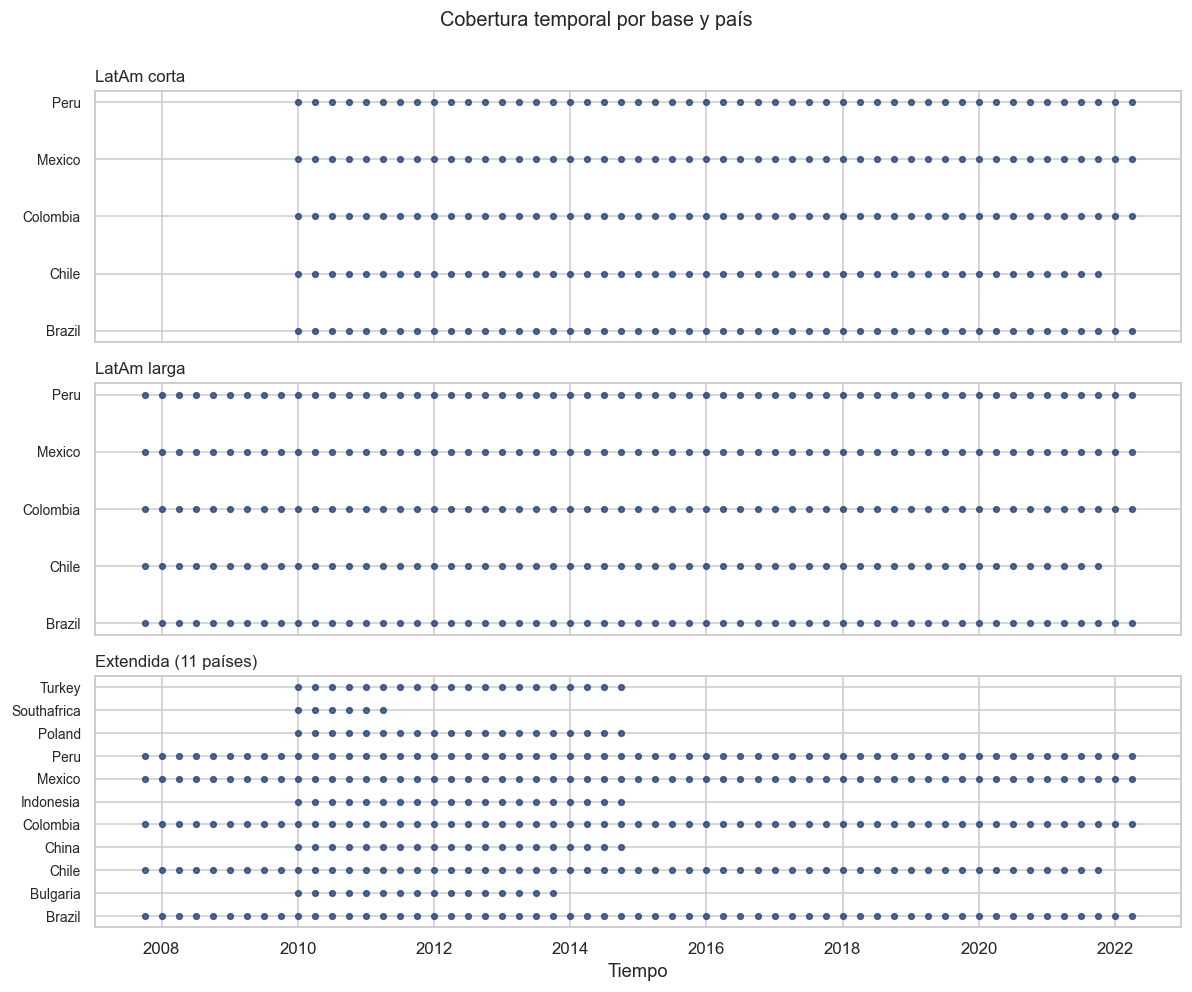

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
bases = [('LatAm corta', corta), ('LatAm larga', larga), ('Extendida (11 países)', ext)]
for ax, (name, d) in zip(axes, bases):
    countries = sorted(d.country.unique())
    for i, c in enumerate(countries):
        sub = d[d.country == c]
        ax.scatter(sub.tnum, [i]*len(sub), s=14, color='#1f3b73', alpha=.75)
    ax.set_yticks(range(len(countries)))
    ax.set_yticklabels([c.capitalize() for c in countries], fontsize=9)
    ax.set_title(name, loc='left', fontsize=11)
axes[-1].set_xlabel('Tiempo')
fig.suptitle('Cobertura temporal por base y país', y=1.0, fontsize=13)
fig.tight_layout()
savefig('14_1_cobertura_tres_bases')
plt.show()

### 14.2 Efecto marginal de JLoss según severidad de GaR — corta vs. larga

Coeficientes de M2 (twoways FE, sin controles) tomados de `Regresiones_panel_v2.Rmd`:
corta $\hat\beta_1=1{,}233$, $\hat\theta=-0{,}352$ (SE 0,427 y 0,089); larga
$\hat\beta_1=1{,}271$, $\hat\theta=-0{,}305$ (SE 0,464 y 0,120).

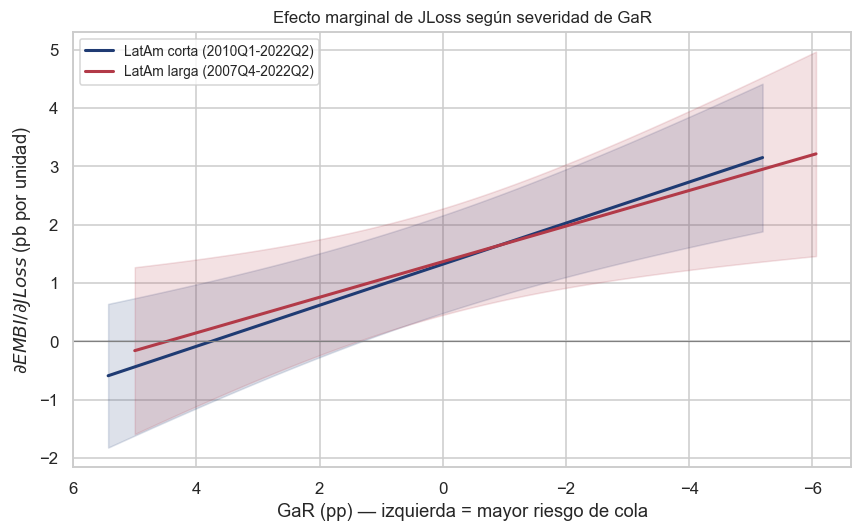

In [28]:
params = {
    'corta': dict(bJ=1.233, bI=-0.352, seJ=0.427, seI=0.089, dat=corta,
                  label='LatAm corta (2010Q1-2022Q2)', color='#1f3b73'),
    'larga': dict(bJ=1.271, bI=-0.305, seJ=0.464, seI=0.120, dat=larga,
                  label='LatAm larga (2007Q4-2022Q2)', color='#b23a48'),
}
fig, ax = plt.subplots(figsize=(8, 5))
for key, p in params.items():
    d = p['dat']
    mu = d['GaR_pp'].mean()
    grid = np.linspace(d['GaR_pp'].quantile(.05), d['GaR_pp'].quantile(.95), 100)
    dev = grid - mu
    me = p['bJ'] + p['bI'] * dev
    se = np.sqrt(p['seJ']**2 + dev**2 * p['seI']**2)
    ax.plot(grid, me, color=p['color'], label=p['label'], linewidth=2)
    ax.fill_between(grid, me - 1.96*se, me + 1.96*se, color=p['color'], alpha=.15)
ax.axhline(0, color='grey', linewidth=.8)
ax.invert_xaxis()
ax.set_xlabel('GaR (pp) — izquierda = mayor riesgo de cola')
ax.set_ylabel(r'$\partial EMBI/\partial JLoss$ (pb por unidad)')
ax.set_title('Efecto marginal de JLoss según severidad de GaR')
ax.legend(fontsize=9)
fig.tight_layout()
savefig('14_2_efecto_marginal_corta_larga')
plt.show()

### 14.3 Síntesis: triangulación de $\theta$ a través de bases y especificaciones

Los doce valores de $\theta$ (y sus errores estándar Driscoll–Kraay) provienen directamente
de `Regresiones_panel_v2.Rmd`, Sección 8 ("Síntesis"). Se reconstruyen aquí para dejar la
figura reproducible junto con el resto del EDA.

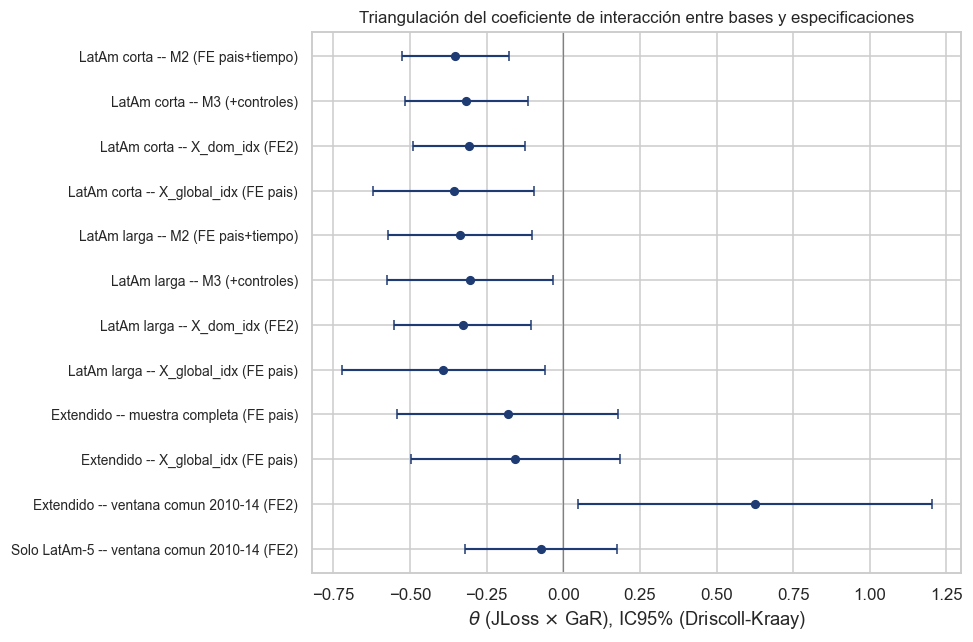

,modelo,theta,se,lo,hi
0,Solo LatAm-5 -- ventana comun 2010-14 (FE2),-0.0739,0.1264,-0.3216,0.1738
1,Extendido -- ventana comun 2010-14 (FE2),0.6257,0.2943,0.0489,1.2025
2,Extendido -- X_global_idx (FE pais),-0.1567,0.1742,-0.4981,0.1847
3,Extendido -- muestra completa (FE pais),-0.1816,0.1832,-0.5407,0.1775
4,LatAm larga -- X_global_idx (FE pais),-0.3909,0.1689,-0.7219,-0.0599
5,LatAm larga -- X_dom_idx (FE2),-0.3272,0.1141,-0.5508,-0.1036
6,LatAm larga -- M3 (+controles),-0.3053,0.1380,-0.5758,-0.0348
7,LatAm larga -- M2 (FE pais+tiempo),-0.3361,0.1197,-0.5707,-0.1015
8,LatAm corta -- X_global_idx (FE pais),-0.3576,0.1334,-0.6191,-0.0961
9,LatAm corta -- X_dom_idx (FE2),-0.3058,0.0932,-0.4885,-0.1231


In [29]:
synth = [
    ('LatAm corta -- M2 (FE pais+tiempo)', -0.3522, 0.0887),
    ('LatAm corta -- M3 (+controles)', -0.3156, 0.1020),
    ('LatAm corta -- X_dom_idx (FE2)', -0.3058, 0.0932),
    ('LatAm corta -- X_global_idx (FE pais)', -0.3576, 0.1334),
    ('LatAm larga -- M2 (FE pais+tiempo)', -0.3361, 0.1197),
    ('LatAm larga -- M3 (+controles)', -0.3053, 0.1380),
    ('LatAm larga -- X_dom_idx (FE2)', -0.3272, 0.1141),
    ('LatAm larga -- X_global_idx (FE pais)', -0.3909, 0.1689),
    ('Extendido -- muestra completa (FE pais)', -0.1816, 0.1832),
    ('Extendido -- X_global_idx (FE pais)', -0.1567, 0.1742),
    ('Extendido -- ventana comun 2010-14 (FE2)', 0.6257, 0.2943),
    ('Solo LatAm-5 -- ventana comun 2010-14 (FE2)', -0.0739, 0.1264),
]
synth = pd.DataFrame(synth, columns=['modelo', 'theta', 'se'])
synth['lo'] = synth.theta - 1.96 * synth.se
synth['hi'] = synth.theta + 1.96 * synth.se
synth = synth.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(synth))
ax.axvline(0, color='grey', linewidth=.8)
ax.errorbar(synth.theta, y, xerr=[synth.theta - synth.lo, synth.hi - synth.theta],
            fmt='o', color='#1f3b73', ecolor='#1f3b73', elinewidth=1.4, capsize=3, markersize=5)
ax.set_yticks(y)
ax.set_yticklabels(synth.modelo, fontsize=9)
ax.set_xlabel(r'$\theta$ (JLoss $\times$ GaR), IC95% (Driscoll-Kraay)')
ax.set_title('Triangulación del coeficiente de interacción entre bases y especificaciones')
fig.tight_layout()
savefig('14_3_forest_theta_sintesis')
plt.show()

synth[['modelo', 'theta', 'se', 'lo', 'hi']]

### 14.4 Nota de lectura

Dentro del núcleo LatAm (ocho primeras filas de la Figura 14.3) $\theta$ es sistemáticamente
negativo y significativo, con y sin los controles del paper de referencia agregados como
índice. Fuera de ese núcleo la evidencia es mixta: la muestra completa del panel extendido
mantiene el signo pero pierde significancia, y la ventana común 2010–2014 exhibe el único
signo positivo del conjunto — justo en el subpanel más heterogéneo (11 países, fuentes de
EMBI mixtas, sin controles domésticos para los 6 países nuevos). Ver Sección 6.5–6.6 del
documento principal (`Boceto_1_v2.tex`) para la discusión completa.

---
# 15. Figuras de resultados basadas en las regresiones — LatAm larga y Extendido

Traslada a esta base el bloque de figuras de `EDA_panel.ipynb` §14 (efecto marginal, superficie de complementariedad, binscatter, forest plot de robustez, umbral de Hansen, series por país, contabilidad de un episodio, contrafactual y *leave-one-country-out*), repitiéndolo para **dos** de las tres bases ya cargadas en la Sección 14: **LatAm larga** (`larga` = `Panel_final.csv`) y **Extendida** (`ext` = `Panel_extended_15paises.csv`). **Se excluye `corta` (`Panel_final_prebackup.csv`)** por quedar oficialmente obsoleta.

La especificación central es la misma en las dos bases ($EMBI_{i,t}=\alpha_i+\lambda_t+\beta_1 JLoss_{i,t}+\beta_2 GaR_{i,t}+\theta\,(JLoss\times GaR)_{i,t}+\gamma' X_{i,t}+\varepsilon_{i,t}$), pero el vector de controles $X$ y la estructura de efectos fijos difieren porque la base extendida no tiene controles domésticos para los 6 países fuera de LatAm (ver `Regresiones_panel_v2.Rmd`, Sección 4):

- **LatAm larga:** FE país+tiempo, controles domésticos completos (`debt_gdp, fisc_bal, res_gdp, ca_gdp, infl_yoy, reer`) — modelo M3 de la batería principal.
- **Extendida:** FE país únicamente (sin FE de tiempo — fuera de 2010Q1-2014Q4 el panel es casi enteramente los 5 países LatAm y el FE de tiempo terminaría absorbiendo esa misma variación), sin controles domésticos — modelo `M_ext_pais` de `Regresiones_panel_v2.Rmd` §4.1. Donde la figura original usa `reer` como control macro adicional (umbral de Hansen), la versión extendida usa `X_global_idx` en su lugar.

Los coeficientes se **reestiman en Python** (`linearmodels.PanelOLS`, SE tipo *kernel* Bartlett ≈ Driscoll-Kraay) sobre los CSV finales — no son los mismos números hardcodeados de la Sección 14 (que vienen de R), pero deberían ser consistentes con ellos salvo por diferencias menores de implementación numérica.


In [30]:
# --- 15.0 Preparación: enriquecer 'larga' y 'ext' (ya cargadas en la Sección 14) y ajustar los modelos base ---
import warnings; warnings.filterwarnings('ignore')
from linearmodels.panel import PanelOLS

DK = dict(cov_type='kernel', kernel='bartlett')

def _enrich(d):
    d = d.copy()
    d['t'] = pd.PeriodIndex(d['quarter'], freq='Q').to_timestamp()
    d['date'] = d['t']
    d['JxG_c'] = d['JLoss_c'] * d['GaR_c']
    if 'ES' in d.columns:
        d['ES_pp'] = d['ES'] * 100
        d['ES_pp_c'] = d['ES_pp'] - d['ES_pp'].mean()
        d['JxES_c'] = d['JLoss_c'] * d['ES_pp_c']
    return d

larga15 = _enrich(larga)
ext15 = _enrich(ext)

def feols(df, formula, **kw):
    Pi = df.set_index(['country', 't'])
    return PanelOLS.from_formula(formula, Pi, **kw).fit(**DK)

CTRL_LARGA = ['debt_gdp', 'fisc_bal', 'res_gdp', 'ca_gdp', 'infl_yoy', 'reer']
FC_LARGA = ' + '.join(CTRL_LARGA)
m3_larga = feols(larga15, f'EMBI_bps ~ JLoss_c + GaR_c + JxG_c + {FC_LARGA} + EntityEffects + TimeEffects')
m3_ext = feols(ext15, 'EMBI_bps ~ JLoss_c + GaR_c + JxG_c + EntityEffects')

BASES15 = {
    'larga': dict(df=larga15, m=m3_larga, label='LatAm larga (2007Q4-2022Q2, 5 países)',
                  color='#1f3b73', ctrl_formula=FC_LARGA),
    'ext':   dict(df=ext15,   m=m3_ext,   label='Extendido (11 países, EMBI real BCRP+GFSR)',
                  color='#b23a48', ctrl_formula=None),
}
for key, b in BASES15.items():
    b['b1'] = b['m'].params['JLoss_c']; b['b2'] = b['m'].params['GaR_c']; b['th'] = b['m'].params['JxG_c']
    b['V'] = b['m'].cov
    b['mu_g'] = b['df']['GaR_pp'].mean()

print('θ (JLoss×GaR) — LatAm larga (FE2+controles):', round(m3_larga.params['JxG_c'], 4),
      '| Extendido (FE país):', round(m3_ext.params['JxG_c'], 4))



θ (JLoss×GaR) — LatAm larga (FE2+controles): -0.3053 | Extendido (FE país): -0.2321


## 15.1 Efecto marginal de JLoss condicional al GaR — figura central

$$\partial EMBI/\partial JLoss = \hat\beta_1 + \hat\theta\,(GaR-\overline{GaR})$$
con banda IC95%, para las dos bases superpuestas en el mismo eje. Análoga a la Fig. 3 de Chari et al. (2024) y a la celda 14.1 de `EDA_panel.ipynb`.


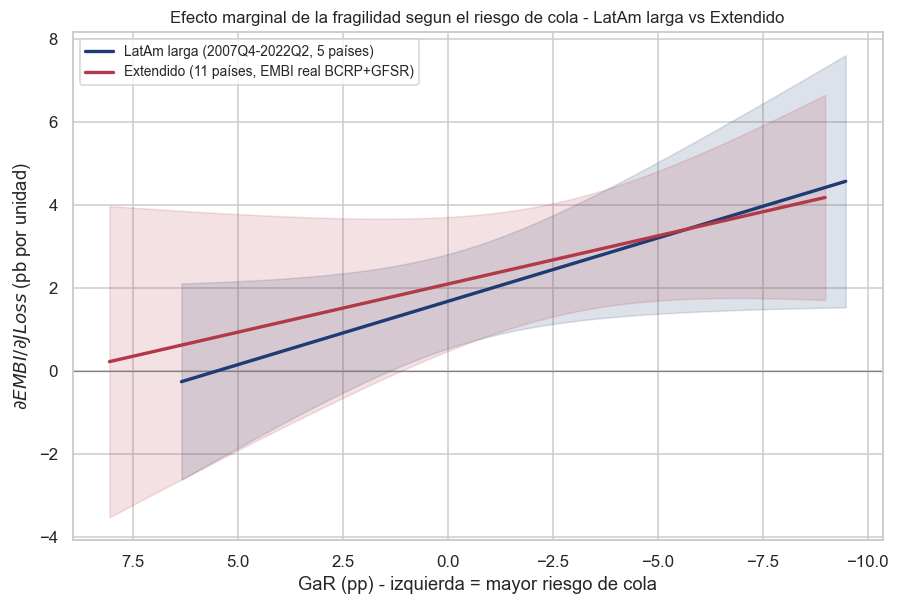

In [31]:
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.axhline(0, color='grey', lw=.8)
for key, b in BASES15.items():
    d, bJ, bI, V, mu_g = b['df'], b['b1'], b['th'], b['V'], b['mu_g']
    vJ, vI, cJI = V.loc['JLoss_c','JLoss_c'], V.loc['JxG_c','JxG_c'], V.loc['JLoss_c','JxG_c']
    grid = np.linspace(d['GaR_pp'].quantile(.02), d['GaR_pp'].quantile(.98), 200)
    dev = grid - mu_g
    me = bJ + bI*dev
    se = np.sqrt(vJ + dev**2*vI + 2*dev*cJI)
    ax.fill_between(grid, me-1.96*se, me+1.96*se, alpha=.15, color=b['color'])
    ax.plot(grid, me, color=b['color'], lw=2.2, label=b['label'])
ax.set_xlabel('GaR (pp) - izquierda = mayor riesgo de cola')
ax.set_ylabel(r'$\partial EMBI/\partial JLoss$ (pb por unidad)')
ax.set_title('Efecto marginal de la fragilidad segun el riesgo de cola - LatAm larga vs Extendido')
ax.invert_xaxis(); ax.legend(fontsize=9)
savefig('15_1_efecto_marginal_dos_bases')

# ============================================================


## 15.2 Superficie de complementariedad

Componente $\hat\beta_1 JLoss + \hat\beta_2 GaR + \hat\theta(JLoss\times GaR)$ sobre la malla $(JLoss, GaR)$, un panel por base. Las curvas de iso-spread se "doblan" hacia la esquina de alta fragilidad y cola severa en ambas.


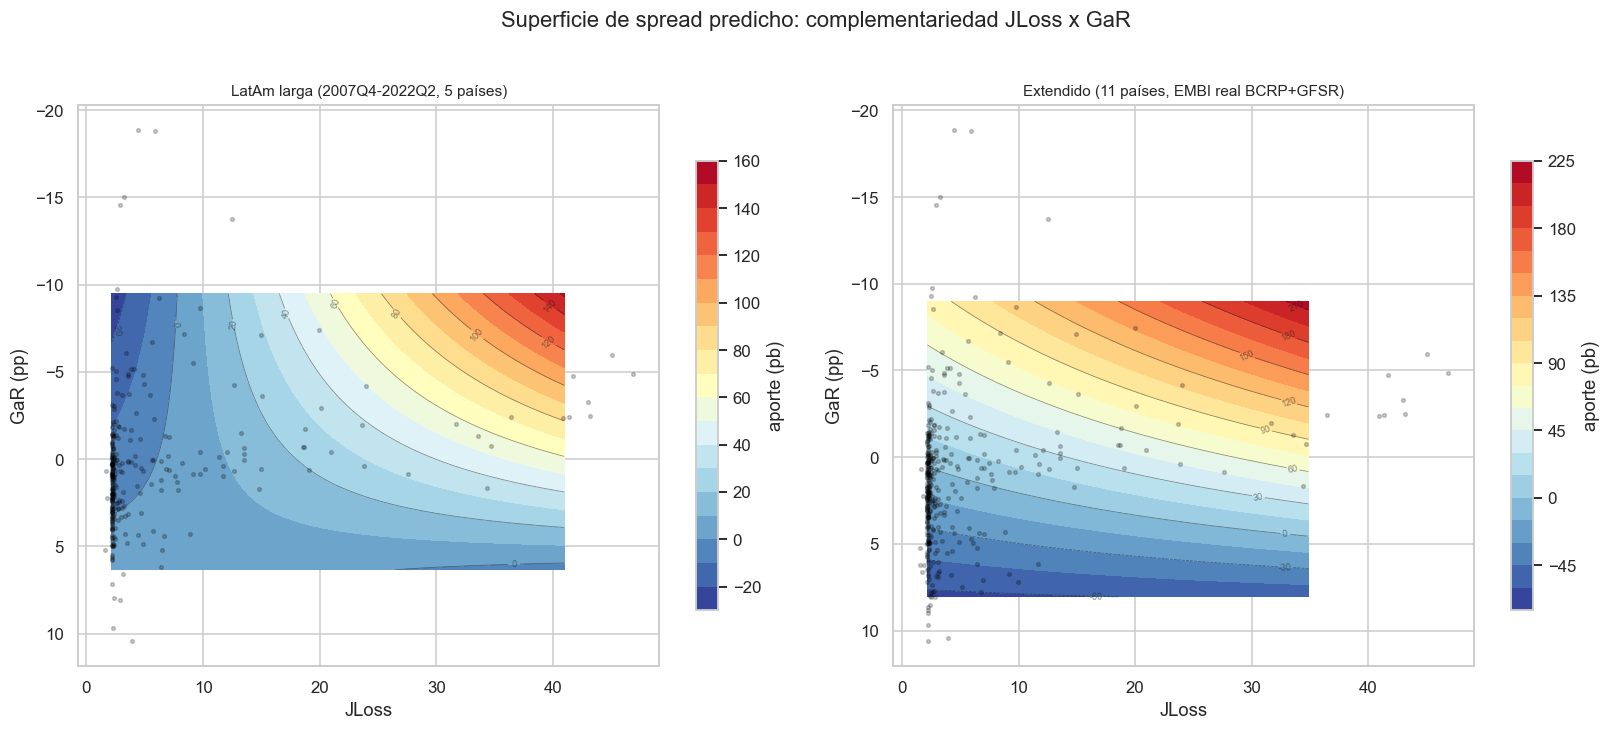

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, (key, b) in zip(axes, BASES15.items()):
    d, b1, b2, th = b['df'], b['b1'], b['b2'], b['th']
    jg = np.linspace(d['JLoss'].quantile(.02), d['JLoss'].quantile(.98), 100)
    gg = np.linspace(d['GaR_pp'].quantile(.02), d['GaR_pp'].quantile(.98), 100)
    JJ, GG = np.meshgrid(jg, gg)
    S = b1*(JJ-d['JLoss'].mean()) + b2*(GG-b['mu_g']) + th*((JJ-d['JLoss'].mean())*(GG-b['mu_g']))
    cf = ax.contourf(JJ, GG, S, levels=18, cmap='RdYlBu_r')
    cs = ax.contour(JJ, GG, S, levels=10, colors='k', linewidths=.5, alpha=.5)
    ax.clabel(cs, inline=True, fontsize=6, fmt='%.0f')
    ax.scatter(d['JLoss'], d['GaR_pp'], s=6, color='black', alpha=.2)
    ax.invert_yaxis()
    ax.set_xlabel('JLoss'); ax.set_ylabel('GaR (pp)')
    ax.set_title(b['label'], fontsize=10)
    fig.colorbar(cf, ax=ax, label='aporte (pb)', shrink=.8)
fig.suptitle('Superficie de spread predicho: complementariedad JLoss x GaR', y=1.02)
fig.tight_layout()
savefig('15_2_superficie_dos_bases')

# ============================================================


## 15.3 Binscatter de EMBI vs JLoss por régimen de GaR

Validación visual **no paramétrica**: se promedia el EMBI en deciles de JLoss dentro de cada tercil de GaR, con recta ajustada por grupo, un panel por base.


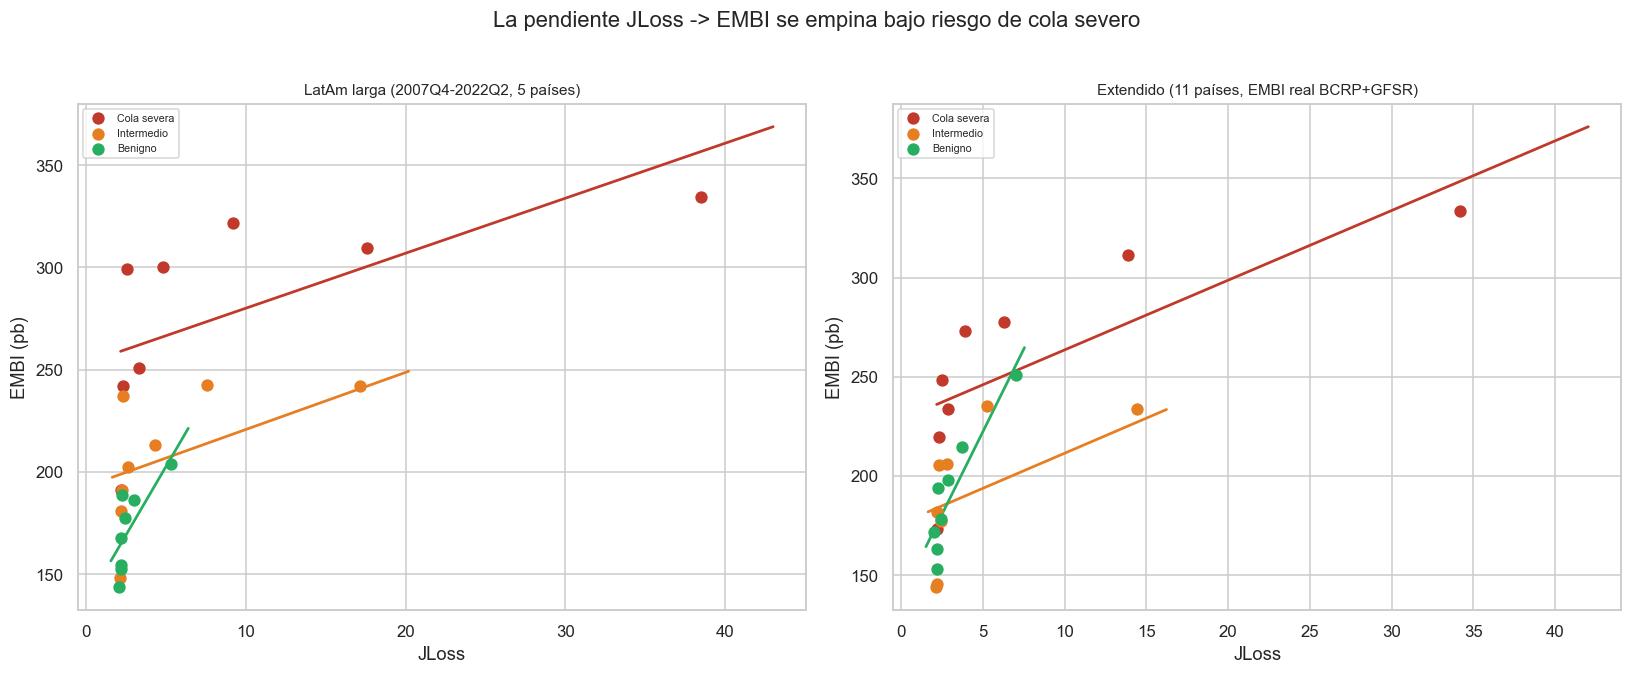

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = {'Cola severa':'#c0392b','Intermedio':'#e67e22','Benigno':'#27ae60'}
for ax, (key, b) in zip(axes, BASES15.items()):
    dd = b['df'].copy()
    dd['terc'] = pd.qcut(dd['GaR_pp'], 3, labels=['Cola severa','Intermedio','Benigno'])
    for terc, g in dd.groupby('terc', observed=True):
        g = g.copy()
        nbins = min(8, g['JLoss'].nunique())
        if nbins < 2: continue
        g['bin'] = pd.qcut(g['JLoss'].rank(method='first'), nbins, labels=False)
        bs = g.groupby('bin').agg(J=('JLoss','mean'), E=('EMBI_bps','mean'))
        ax.scatter(bs['J'], bs['E'], color=palette[terc], s=50, zorder=4, label=terc)
        bcoef = np.polyfit(g['JLoss'], g['EMBI_bps'], 1)
        xs = np.linspace(g['JLoss'].min(), g['JLoss'].quantile(.97), 50)
        ax.plot(xs, np.polyval(bcoef, xs), color=palette[terc], lw=1.8)
    ax.set_xlabel('JLoss'); ax.set_ylabel('EMBI (pb)')
    ax.set_title(b['label'], fontsize=10)
    ax.legend(fontsize=7)
fig.suptitle('La pendiente JLoss -> EMBI se empina bajo riesgo de cola severo', y=1.02)
fig.tight_layout()
savefig('15_3_binscatter_dos_bases')


# ============================================================


## 15.4 *Forest plot* de θ: robustez en una imagen

Coeficiente de interacción y su IC95% a través de especificaciones alternativas — **una figura por base**, porque el conjunto de variantes disponible difiere: LatAm larga reutiliza la batería de `EDA_panel.ipynb` (M2, M3, clusters, sin-COVID, sin-deuda, cola=ES); la base Extendida usa las variantes que sí tienen sentido con sus datos (FE país base, +VIX CBOE, +`X_global_idx`, FE país+tiempo, clusters, cola=ES).


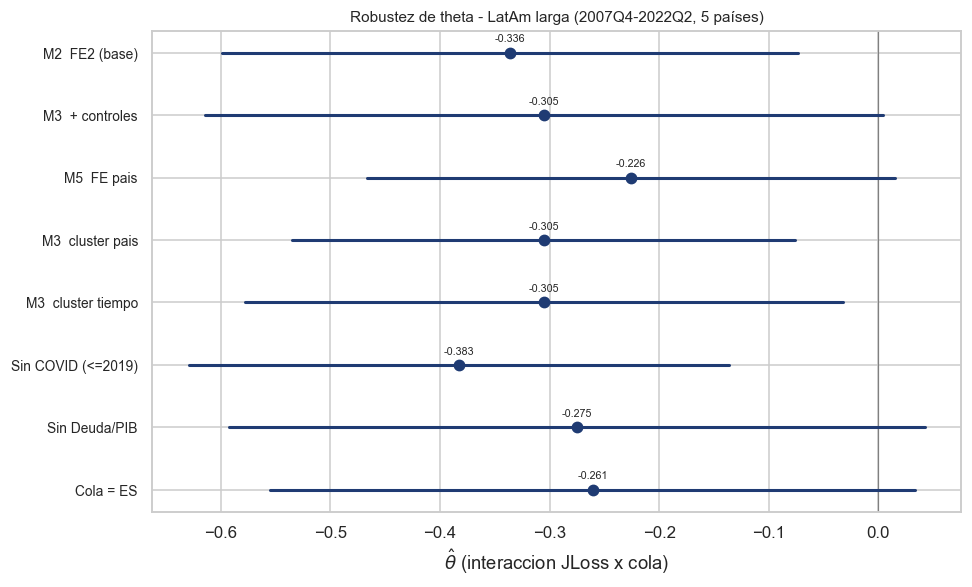

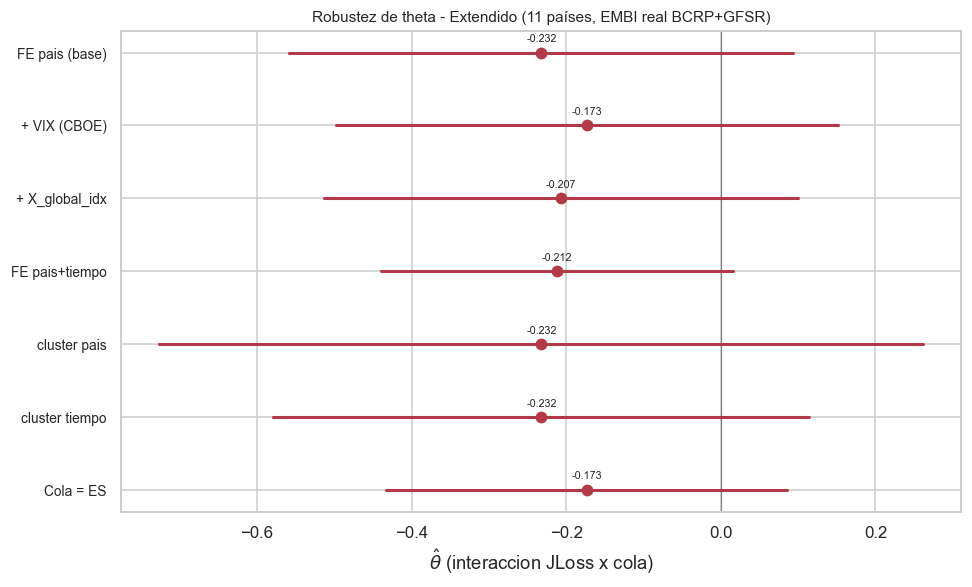

In [34]:
def forest_larga(b):
    d = b['df']; rows = []
    def addrow(lbl, est, se): rows.append((lbl, est, est-1.96*se, est+1.96*se))
    m2 = feols(d, 'EMBI_bps ~ JLoss_c + GaR_c + JxG_c + EntityEffects + TimeEffects')
    addrow('M2  FE2 (base)', m2.params['JxG_c'], m2.std_errors['JxG_c'])
    addrow('M3  + controles', b['m'].params['JxG_c'], b['m'].std_errors['JxG_c'])
    m5 = feols(d, f"EMBI_bps ~ JLoss_c + GaR_c + JxG_c + VIX + {b['ctrl_formula']} + EntityEffects")
    addrow('M5  FE pais', m5.params['JxG_c'], m5.std_errors['JxG_c'])
    Pi = d.set_index(['country','t'])
    m3_ce = PanelOLS.from_formula(f"EMBI_bps ~ JLoss_c + GaR_c + JxG_c + {b['ctrl_formula']} + EntityEffects + TimeEffects", Pi).fit(cov_type='clustered', cluster_entity=True)
    addrow('M3  cluster pais', m3_ce.params['JxG_c'], m3_ce.std_errors['JxG_c'])
    m3_ct = PanelOLS.from_formula(f"EMBI_bps ~ JLoss_c + GaR_c + JxG_c + {b['ctrl_formula']} + EntityEffects + TimeEffects", Pi).fit(cov_type='clustered', cluster_time=True)
    addrow('M3  cluster tiempo', m3_ct.params['JxG_c'], m3_ct.std_errors['JxG_c'])
    sub = d[d['year'] < 2020]
    m_nc = feols(sub, f"EMBI_bps ~ JLoss_c + GaR_c + JxG_c + {b['ctrl_formula']} + EntityEffects + TimeEffects")
    addrow('Sin COVID (<=2019)', m_nc.params['JxG_c'], m_nc.std_errors['JxG_c'])
    FCnd = ' + '.join([c for c in b['ctrl_formula'].split(' + ') if c != 'debt_gdp'])
    m_nd = feols(d, f'EMBI_bps ~ JLoss_c + GaR_c + JxG_c + {FCnd} + EntityEffects + TimeEffects')
    addrow('Sin Deuda/PIB', m_nd.params['JxG_c'], m_nd.std_errors['JxG_c'])
    m6 = feols(d, f"EMBI_bps ~ JLoss_c + ES_pp_c + JxES_c + {b['ctrl_formula']} + EntityEffects + TimeEffects")
    addrow('Cola = ES', m6.params['JxES_c'], m6.std_errors['JxES_c'])
    return rows

def forest_ext(b):
    d = b['df']; rows = []
    def addrow(lbl, est, se): rows.append((lbl, est, est-1.96*se, est+1.96*se))
    addrow('FE pais (base)', b['m'].params['JxG_c'], b['m'].std_errors['JxG_c'])
    m_vix = feols(d, 'EMBI_bps ~ JLoss_c + GaR_c + JxG_c + VIX_cboe + EntityEffects')
    addrow('+ VIX (CBOE)', m_vix.params['JxG_c'], m_vix.std_errors['JxG_c'])
    m_glob = feols(d, 'EMBI_bps ~ JLoss_c + GaR_c + JxG_c + X_global_idx + EntityEffects')
    addrow('+ X_global_idx', m_glob.params['JxG_c'], m_glob.std_errors['JxG_c'])
    m_2w = feols(d, 'EMBI_bps ~ JLoss_c + GaR_c + JxG_c + EntityEffects + TimeEffects')
    addrow('FE pais+tiempo', m_2w.params['JxG_c'], m_2w.std_errors['JxG_c'])
    Pi = d.set_index(['country','t'])
    m_ce = PanelOLS.from_formula('EMBI_bps ~ JLoss_c + GaR_c + JxG_c + EntityEffects', Pi).fit(cov_type='clustered', cluster_entity=True)
    addrow('cluster pais', m_ce.params['JxG_c'], m_ce.std_errors['JxG_c'])
    m_ct = PanelOLS.from_formula('EMBI_bps ~ JLoss_c + GaR_c + JxG_c + EntityEffects', Pi).fit(cov_type='clustered', cluster_time=True)
    addrow('cluster tiempo', m_ct.params['JxG_c'], m_ct.std_errors['JxG_c'])
    m6 = feols(d, 'EMBI_bps ~ JLoss_c + ES_pp_c + JxES_c + EntityEffects')
    addrow('Cola = ES', m6.params['JxES_c'], m6.std_errors['JxES_c'])
    return rows

FOREST_FN = {'larga': forest_larga, 'ext': forest_ext}
for key, b in BASES15.items():
    rows = FOREST_FN[key](b)
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.axvline(0, color='grey', lw=.8)
    for i, (lbl, est, l, h) in enumerate(rows):
        ax.plot([l,h], [i,i], color=b['color'], lw=2)
        ax.scatter([est], [i], color=b['color'], zorder=5, s=45)
        ax.annotate(f'{est:+.3f}', (est,i), textcoords='offset points', xytext=(0,7), ha='center', fontsize=7)
    ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows], fontsize=9)
    ax.set_xlabel(r'$\hat\theta$ (interaccion JLoss x cola)')
    ax.set_title(f"Robustez de theta - {b['label']}", fontsize=10)
    ax.invert_yaxis()
    fig.tight_layout()
    savefig(f'15_4_forest_theta_{key}')



## 15.5 Modelo de umbral de Hansen (Sección 4.3.3)

Umbral $\hat\gamma$ del GaR que separa el régimen de cola severa del benigno (Hansen 1999/2000, one-way dentro de país), una fila por base. El control macro adicional dentro del within-transform es `reer` en LatAm larga y `X_global_idx` en la Extendida (no hay `reer` fuera de LatAm).


larga: umbral=2.430 IC95=[-3.61,3.94]  beta_severo=2.809 beta_benigno=-1.221
ext: umbral=-2.811 IC95=[-3.00,6.04]  beta_severo=4.734 beta_benigno=2.155


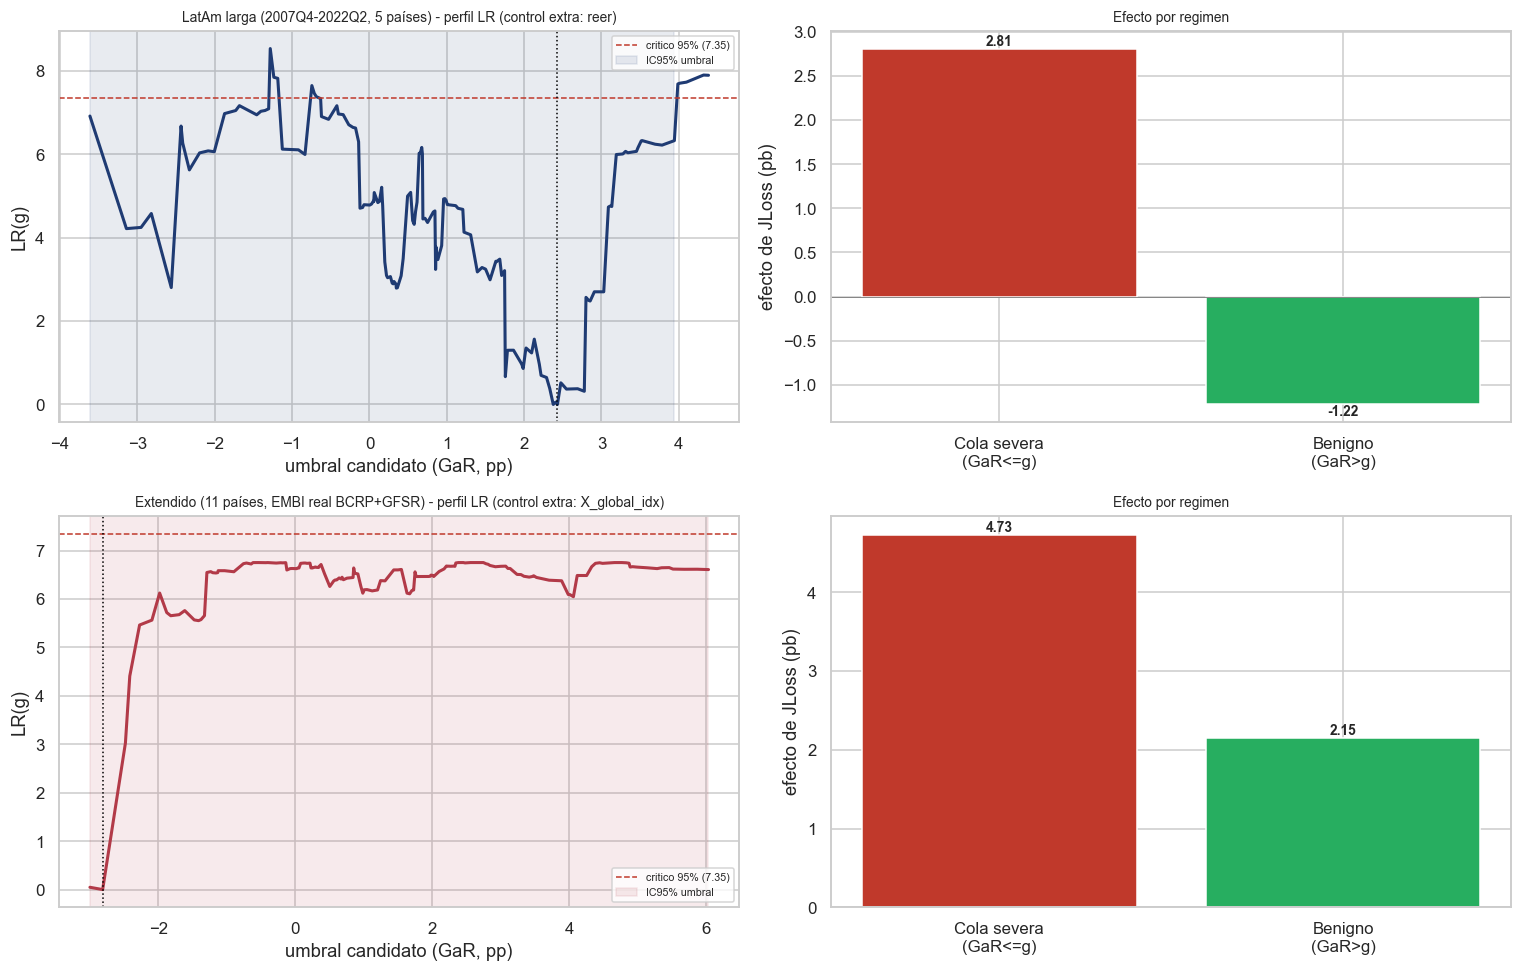

In [35]:
def hansen_fit(d, extra_col):
    d = d.dropna(subset=['EMBI_bps','JLoss','GaR_pp',extra_col]).copy()
    g = d['country']
    def wc(s): return (s - s.groupby(g.values).transform('mean')).values
    yw = wc(d['EMBI_bps']); Jw = wc(d['JLoss']); Gw = wc(d['GaR_pp']); Xw = wc(d[extra_col])
    q = d['GaR_pp'].values; n = len(yw)
    def ssr_beta(gam):
        dlo = (q <= gam).astype(float)
        X = np.column_stack([Jw*dlo, Jw*(1-dlo), Gw, Xw])
        beta, *_ = np.linalg.lstsq(X, yw, rcond=None)
        e = yw - X@beta
        return float(e@e), beta
    grid = np.quantile(q, np.linspace(.10,.90,150))
    res = [ssr_beta(gm) for gm in grid]
    ssrs = np.array([r[0] for r in res])
    ihat = ssrs.argmin(); gam_hat = grid[ihat]; ssr_min = ssrs[ihat]
    sig2 = ssr_min/n; LR = (ssrs-ssr_min)/sig2; crit = 7.35
    inside = grid[LR <= crit]
    ci_lo, ci_hi = inside.min(), inside.max()
    beta_lo, beta_hi = res[ihat][1][0], res[ihat][1][1]
    return grid, LR, crit, gam_hat, ci_lo, ci_hi, beta_lo, beta_hi

HANSEN_EXTRA = {'larga': 'reer', 'ext': 'X_global_idx'}
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, (key, b) in enumerate(BASES15.items()):
    extra = HANSEN_EXTRA[key]
    grid, LR, crit, gam_hat, ci_lo, ci_hi, beta_lo, beta_hi = hansen_fit(b['df'], extra)
    ax0, ax1 = axes[row]
    ax0.plot(grid, LR, color=b['color'], lw=2)
    ax0.axhline(crit, color='#c0392b', ls='--', lw=1, label='critico 95% (7.35)')
    ax0.axvline(gam_hat, color='black', ls=':', lw=1)
    ax0.axvspan(ci_lo, ci_hi, color=b['color'], alpha=.10, label='IC95% umbral')
    ax0.annotate(f'g={gam_hat:.2f} pp', (gam_hat, crit*1.4), fontsize=9)
    ax0.set_xlabel('umbral candidato (GaR, pp)'); ax0.set_ylabel('LR(g)')
    ax0.set_title(f"{b['label']} - perfil LR (control extra: {extra})", fontsize=9); ax0.legend(fontsize=7)
    ax1.bar(['Cola severa\n(GaR<=g)','Benigno\n(GaR>g)'], [beta_lo, beta_hi], color=['#c0392b','#27ae60'])
    ax1.axhline(0, color='grey', lw=.6)
    for i,v in enumerate([beta_lo,beta_hi]):
        ax1.annotate(f'{v:.2f}', (i,v), ha='center', va='bottom' if v>=0 else 'top', fontsize=9, fontweight='bold')
    ax1.set_ylabel('efecto de JLoss (pb)'); ax1.set_title('Efecto por regimen', fontsize=9)
    print(f'{key}: umbral={gam_hat:.3f} IC95=[{ci_lo:.2f},{ci_hi:.2f}]  beta_severo={beta_lo:.3f} beta_benigno={beta_hi:.3f}')
fig.tight_layout()
savefig('15_5_umbral_hansen_dos_bases')



## 15.6 Series de tiempo por país: JLoss, GaR y EMBI

JLoss y GaR (ejes gemelos) con EMBI superpuesto, un panel por país — grilla dimensionada según el número de países de cada base (5 en LatAm larga, 11 en la Extendida).


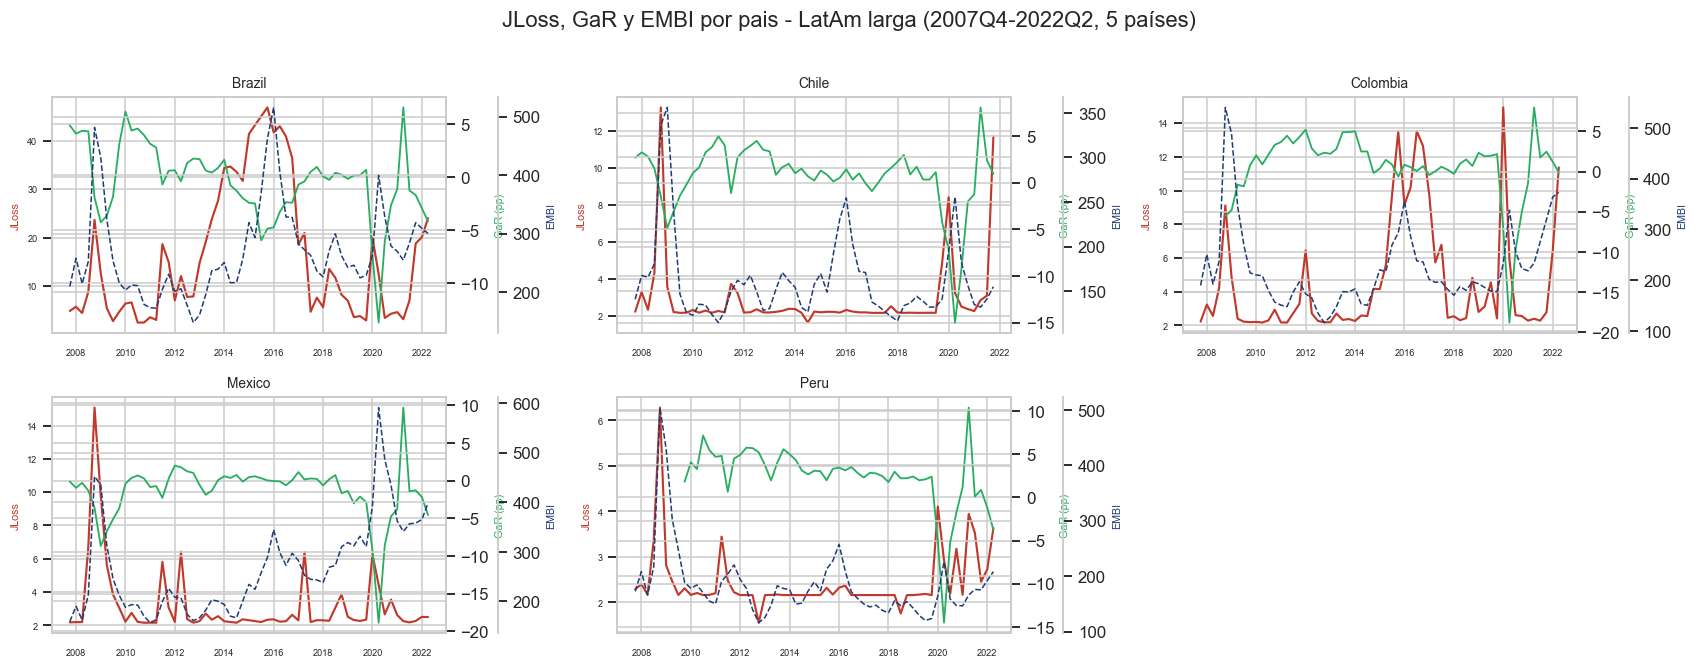

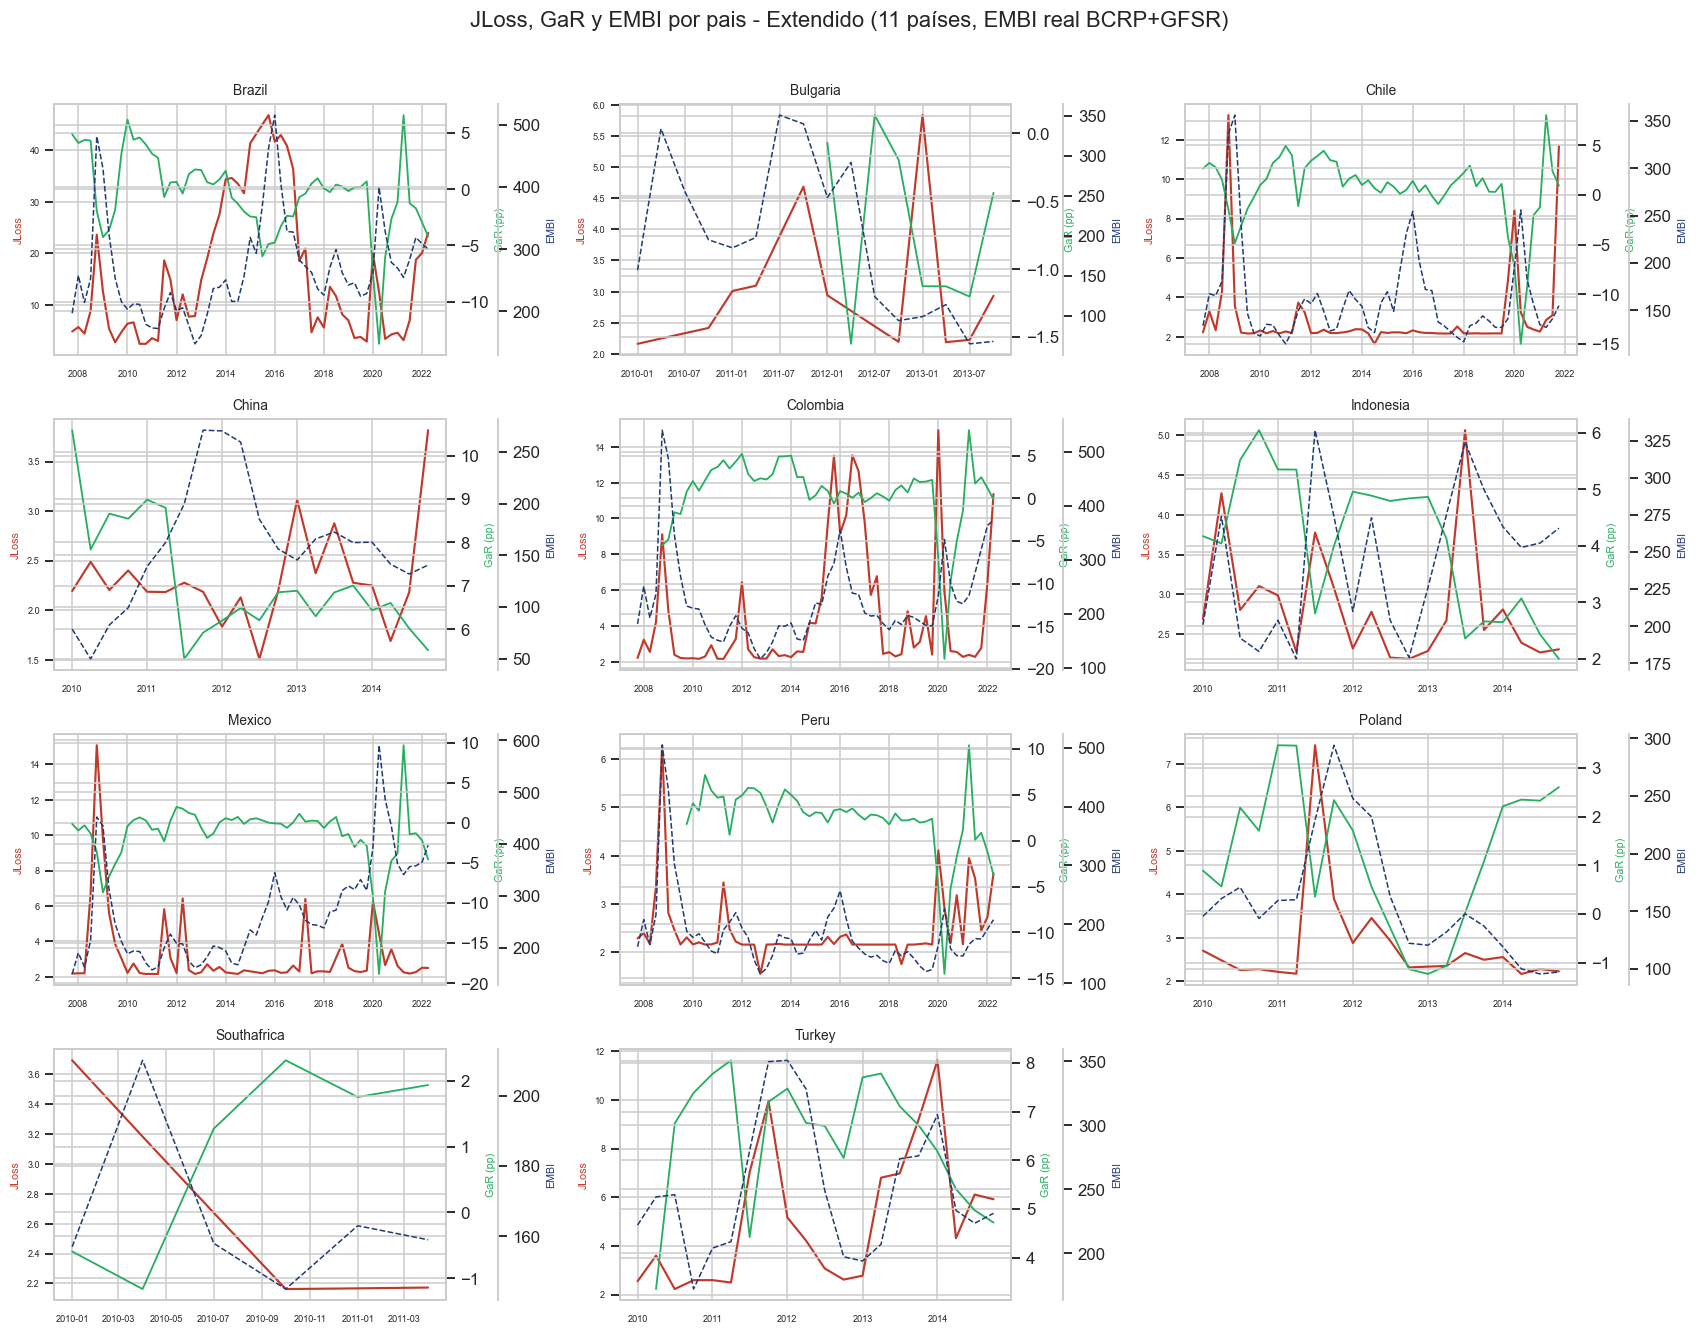

In [36]:
for key, b in BASES15.items():
    d = b['df']; countries = sorted(d['country'].unique()); n = len(countries)
    ncols = 3; nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 3*nrows)); axes = np.atleast_1d(axes).ravel()
    for i, c in enumerate(countries):
        gg = d[d.country==c].sort_values('date'); ax = axes[i]
        ax.plot(gg['date'], gg['JLoss'], color='#c0392b', lw=1.4)
        ax.set_ylabel('JLoss', color='#c0392b', fontsize=7)
        a2 = ax.twinx(); a2.plot(gg['date'], gg['GaR_pp'], color='#27ae60', lw=1.2)
        a2.set_ylabel('GaR (pp)', color='#27ae60', fontsize=7)
        a3 = ax.twinx(); a3.spines['right'].set_position(('outward', 34))
        a3.plot(gg['date'], gg['EMBI_bps'], color='#1f3b73', lw=1.0, ls='--')
        a3.set_ylabel('EMBI', color='#1f3b73', fontsize=7)
        ax.set_title(c.capitalize(), fontsize=9); ax.tick_params(labelsize=6)
    for j in range(n, len(axes)): axes[j].axis('off')
    fig.suptitle(f"JLoss, GaR y EMBI por pais - {b['label']}", y=1.01)
    fig.tight_layout()
    savefig(f'15_6_series_pais_{key}')



## 15.7 Contabilidad del spread en un episodio

Descomposición del cambio predicho del spread en aportes de JLoss, GaR y la interacción, para Brasil en el shock COVID (2019Q4→2020Q2) — presente en ambas bases, lo que permite comparar directamente cuánta amplificación atribuye cada especificación al mismo episodio.


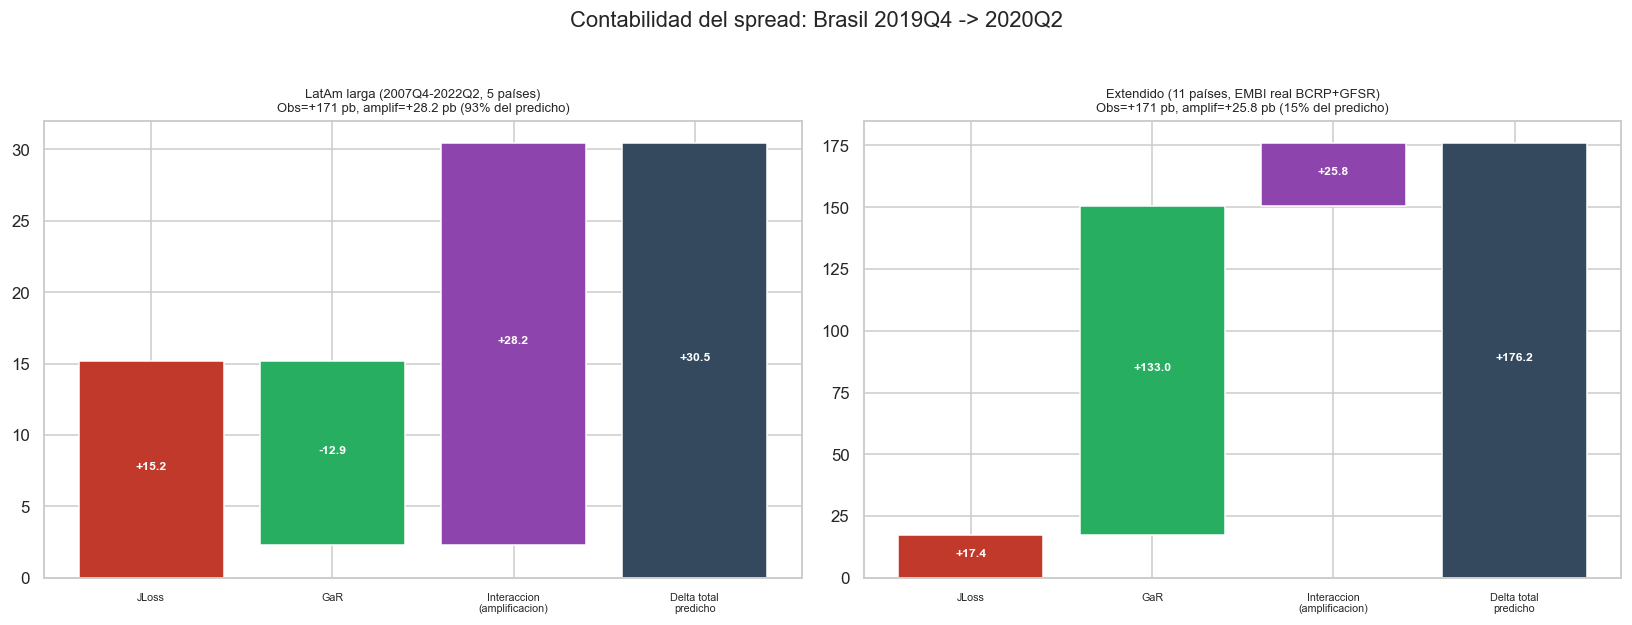

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, (key, b) in zip(axes, BASES15.items()):
    d, b1, b2, th = b['df'], b['b1'], b['b2'], b['th']
    country, q0, q1 = 'brazil', '2019Q4', '2020Q2'
    rows_ = d[(d.country==country) & (d.quarter.isin([q0,q1]))]
    if rows_['quarter'].nunique() < 2:
        ax.text(.5,.5,f'Sin datos para {country} {q0}->{q1}', ha='center'); ax.set_title(b['label'], fontsize=10)
        continue
    a = d[(d.country==country)&(d.quarter==q0)].iloc[0]
    c_ = d[(d.country==country)&(d.quarter==q1)].iloc[0]
    dJ = c_['JLoss_c']-a['JLoss_c']; dG = c_['GaR_c']-a['GaR_c']
    dInt = c_['JLoss_c']*c_['GaR_c'] - a['JLoss_c']*a['GaR_c']
    comp = {'JLoss': b1*dJ, 'GaR': b2*dG, 'Interaccion\n(amplificacion)': th*dInt}
    labels = list(comp); vals = list(comp.values())
    cum = np.cumsum([0]+vals[:-1]); colors=['#c0392b','#27ae60','#8e44ad']
    for i,(l,v) in enumerate(zip(labels,vals)):
        ax.bar(i, v, bottom=cum[i], color=colors[i])
        ax.annotate(f'{v:+.1f}', (i, cum[i]+v/2), ha='center', fontsize=8, fontweight='bold', color='white')
    ax.bar(len(labels), sum(vals), color='#34495e')
    ax.annotate(f'{sum(vals):+.1f}', (len(labels), sum(vals)/2), ha='center', fontsize=8, fontweight='bold', color='white')
    ax.set_xticks(range(len(labels)+1)); ax.set_xticklabels(labels+['Delta total\npredicho'], fontsize=7)
    ax.axhline(0, color='grey', lw=.6)
    dEMBI_obs = c_['EMBI_bps']-a['EMBI_bps']
    share = th*dInt
    ax.set_title(f"{b['label']}\nObs={dEMBI_obs:+.0f} pb, amplif={share:+.1f} pb ({share/sum(vals)*100:.0f}% del predicho)", fontsize=8.5)
fig.suptitle(f'Contabilidad del spread: Brasil 2019Q4 -> 2020Q2', y=1.03)
fig.tight_layout()
savefig('15_7_contabilidad_episodio_dos_bases')



## 15.8 Contrafactual "sin *doom loop*" (θ = 0)

Prima de amplificación $\hat\theta\cdot(JLoss_c\times GaR_c)$ por país en el tiempo, un panel por base.


larga: prima media positiva=5.30 pb, max=75.1 pb
ext: prima media positiva=3.99 pb, max=66.5 pb


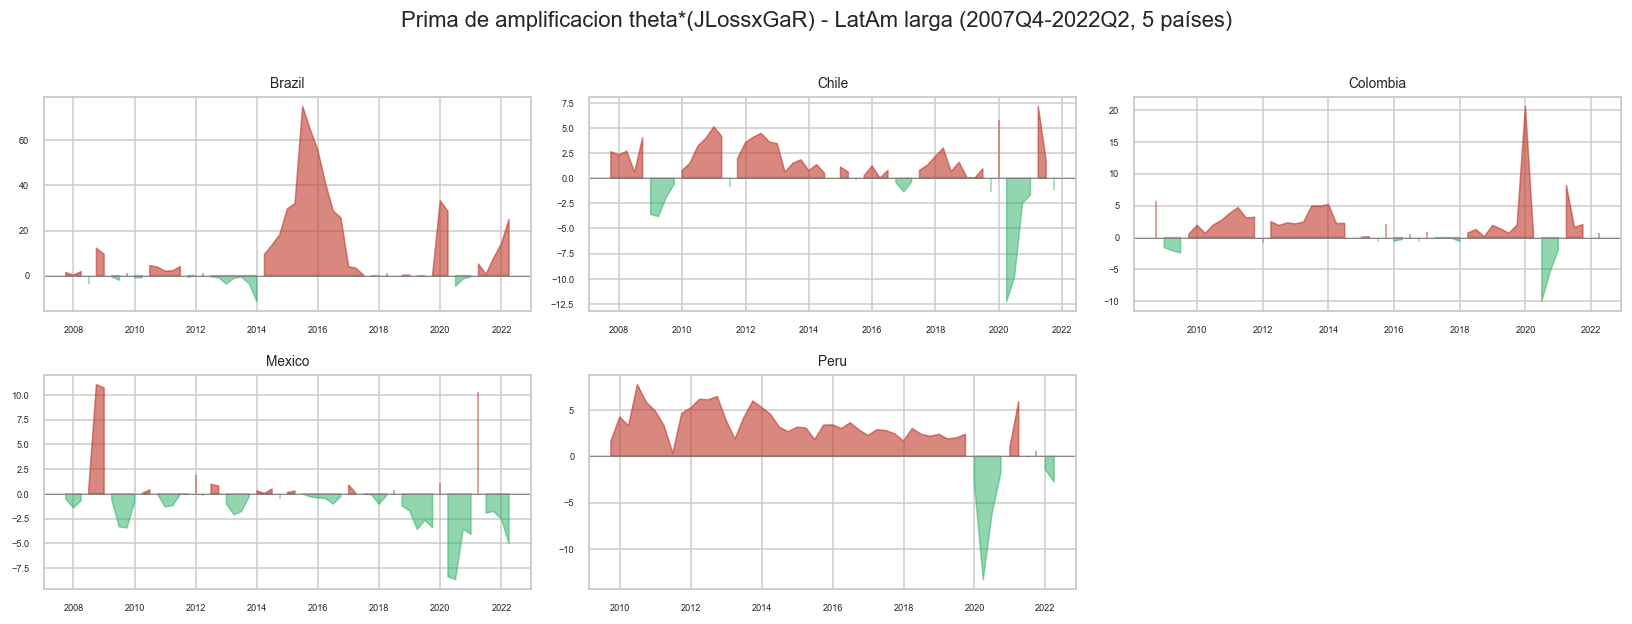

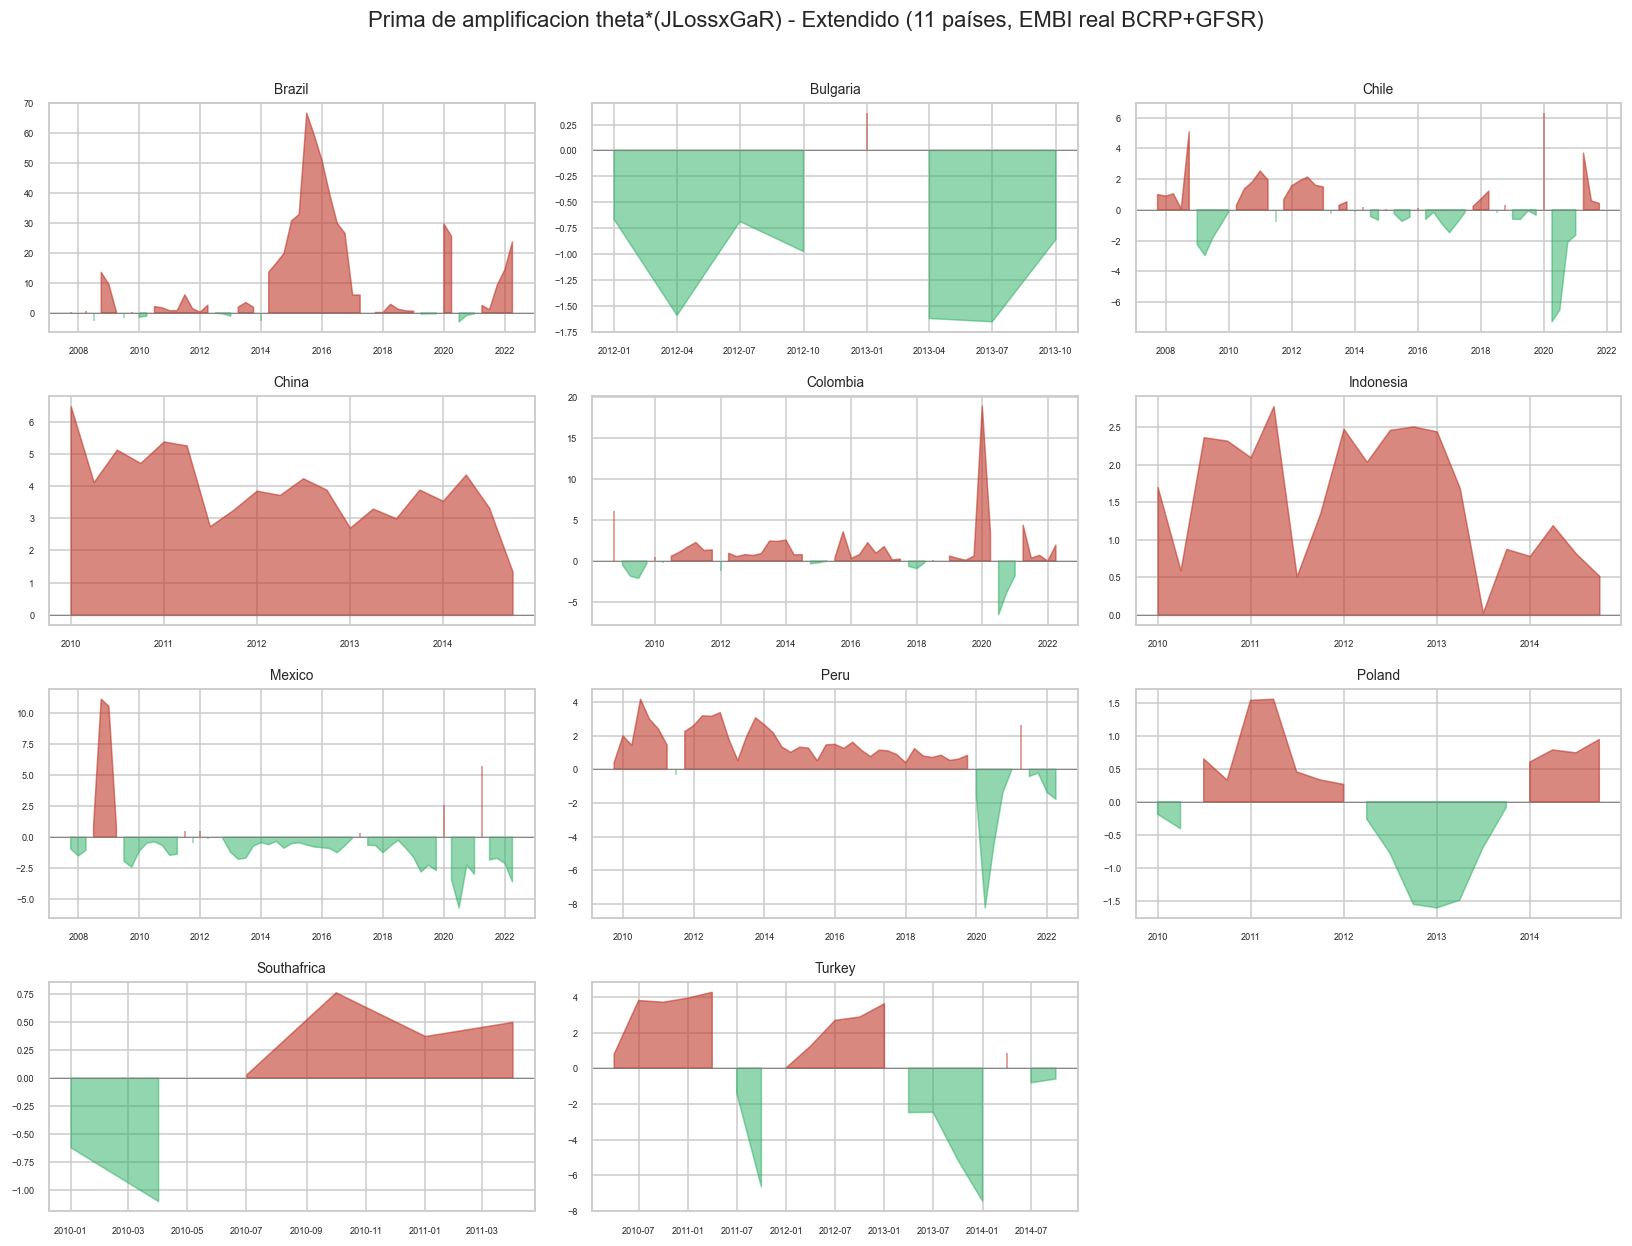

In [38]:
for key, b in BASES15.items():
    d = b['df'].copy(); th = b['th']
    d['amp_premium'] = th * d['JLoss_c'] * d['GaR_c']
    countries = sorted(d['country'].unique()); n = len(countries)
    ncols = 3; nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 2.8*nrows)); axes = np.atleast_1d(axes).ravel()
    for i, c in enumerate(countries):
        gg = d[d.country==c].sort_values('date'); ax = axes[i]
        ax.fill_between(gg['date'], 0, gg['amp_premium'], where=gg['amp_premium']>=0, color='#c0392b', alpha=.6)
        ax.fill_between(gg['date'], 0, gg['amp_premium'], where=gg['amp_premium']<0, color='#27ae60', alpha=.5)
        ax.axhline(0, color='grey', lw=.6); ax.set_title(c.capitalize(), fontsize=9); ax.tick_params(labelsize=6)
    for j in range(n, len(axes)): axes[j].axis('off')
    fig.suptitle(f"Prima de amplificacion theta*(JLossxGaR) - {b['label']}", y=1.01)
    fig.tight_layout()
    savefig(f'15_8_contrafactual_{key}')
    pos = d.loc[d['amp_premium']>0,'amp_premium']
    print(f"{key}: prima media positiva={pos.mean() if len(pos) else float('nan'):.2f} pb, max={d['amp_premium'].max():.1f} pb")

# ============================================================


## 15.9 Heterogeneidad *leave-one-country-out*

Se reestima θ excluyendo cada país, uno a la vez — una figura por base (5+1 filas en LatAm larga, 11+1 en la Extendida), con la misma especificación base de cada una (M2 FE2 en LatAm larga; FE país en la Extendida).


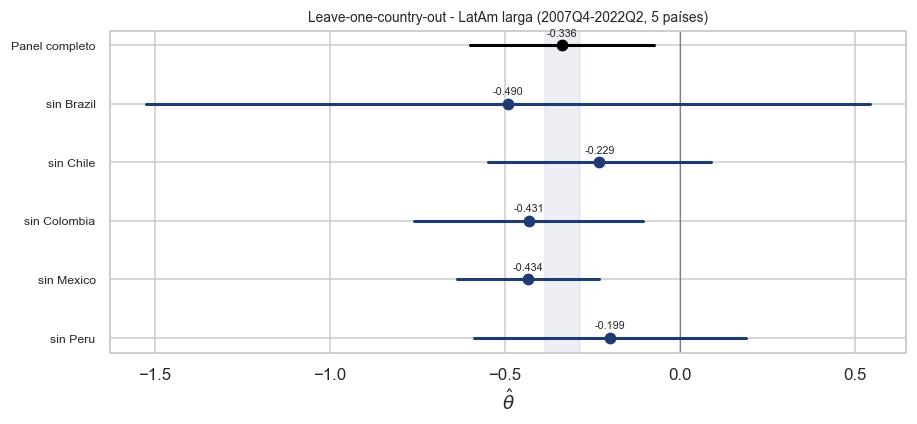

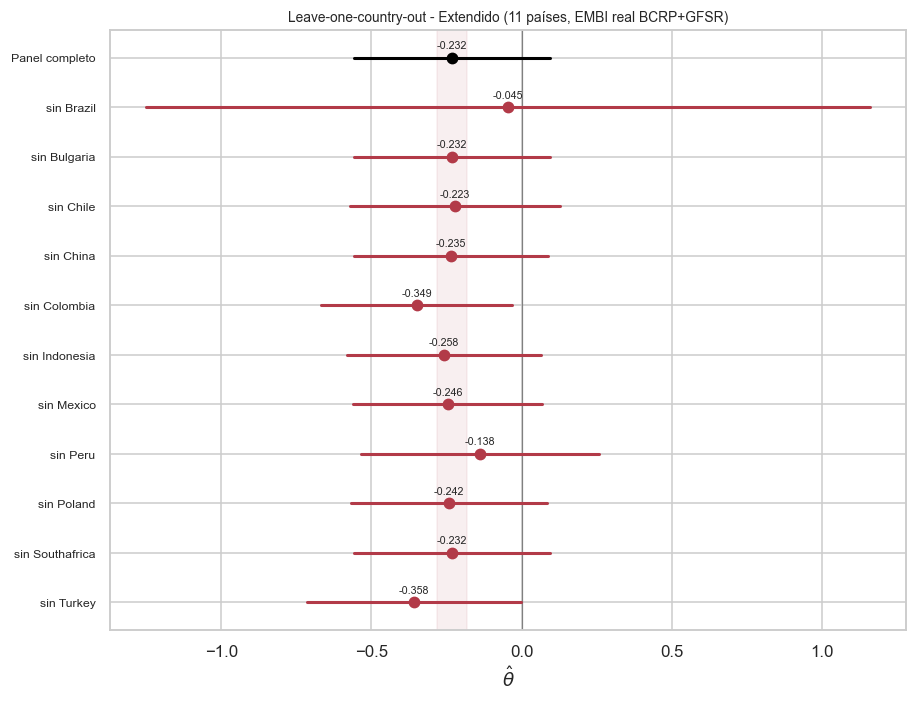

In [39]:
LOO_FORMULA = {
    'larga': lambda d: 'EMBI_bps ~ JLoss_c + GaR_c + JxG_c + EntityEffects + TimeEffects',
    'ext':   lambda d: 'EMBI_bps ~ JLoss_c + GaR_c + JxG_c + EntityEffects',
}
for key, b in BASES15.items():
    d = b['df']; formula = LOO_FORMULA[key](d)
    full = feols(d, formula)
    rows = [('Panel completo', full.params['JxG_c'], full.std_errors['JxG_c'])]
    for c in sorted(d['country'].unique()):
        sub = d[d.country != c]
        r = feols(sub, formula)
        rows.append((f'sin {c.capitalize()}', r.params['JxG_c'], r.std_errors['JxG_c']))
    fig, ax = plt.subplots(figsize=(8.5, 0.42*len(rows)+1.5))
    ax.axvline(0, color='grey', lw=.8)
    ax.axvspan(full.params['JxG_c']-0.05, full.params['JxG_c']+0.05, color=b['color'], alpha=.08)
    for i,(lbl,est,se) in enumerate(rows):
        col = 'black' if lbl=='Panel completo' else b['color']
        ax.plot([est-1.96*se, est+1.96*se],[i,i], color=col, lw=2)
        ax.scatter([est],[i], color=col, s=45, zorder=5)
        ax.annotate(f'{est:+.3f}', (est,i), textcoords='offset points', xytext=(0,6), ha='center', fontsize=7)
    ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows], fontsize=8)
    ax.set_xlabel(r'$\hat\theta$'); ax.invert_yaxis()
    ax.set_title(f"Leave-one-country-out - {b['label']}", fontsize=9)
    fig.tight_layout()
    savefig(f'15_9_leave_one_out_{key}')
